# 1. Introduction 
Time series forecasting plays a central role in meteorology, environmental monitoring, and climate‑aware decision‑making. The availability of long‑term, high‑resolution atmospheric measurements enables the development of deep learning models capable of capturing complex temporal dependencies and nonlinear relationships.

This project focuses on the Jena Climate dataset, a multivariate meteorological time series collected between 2009 and 2016 at the Max Planck Institute for Biogeochemistry. The dataset contains 14 environmental variables recorded every 10 minutes, including temperature, pressure, humidity, and wind-related measurements. As stated in the dataset description, “The dataset consists of 14 features recorded once per 10 minutes.”

The objective of this work is to develop an end‑to‑end forecasting system capable of predicting future air temperature over a fixed prediction horizon. Following the project guidelines, the task is formulated as a multivariate‑input, univariate‑output, multi‑step forecasting problem, where past meteorological observations are used to predict the next 24 hours of temperature.

To address this challenge, we implement and evaluate deep learning architectures designed for sequential data, with a particular focus on Gated Recurrent Units (GRU). The project includes exploratory data analysis, data preprocessing, windowing strategies, model development, hyperparameter optimization, and performance evaluation. The resulting analysis provides insight into the behaviour, strengths, and limitations of recurrent neural networks in meteorological forecasting.

# 2. Methodology

## 2.1 Computational Environment

The experiments were conducted using Python and a set of widely adopted scientific computing libraries. Data manipulation and preprocessing were performed using pandas and numpy, while matplotlib was used for exploratory visualizations. The deep learning models were implemented with TensorFlow/Keras, which provides efficient tools for constructing and training recurrent neural networks such as GRUs.

Additional utilities included scikit‑learn for normalization and evaluation metrics (MAE, RMSE, R²), Optuna for hyperparameter optimization, and standard Python modules such as random and time for reproducibility and runtime management.

This computational setup ensures a robust and reproducible environment for all stages of the forecasting pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras import activations as activations
from keras import applications as applications
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
import time
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


2026-03-03 10:39:37.405632: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 10:39:37.624882: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 10:39:38.683809: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/tqdm/auto.py:21: T

## 2.2 Dataset Description

The dataset used in this project is the Jena Climate dataset, recorded by the [Max Planck Institute for Biogeochemistry](https://www.bgc-jena.mpg.de/wetter/). It contains 14 meteorological variables measured every 10 minutes over the period January 10 2009 to December 31 2016. According to the dataset documentation, “The dataset consists of 14 features recorded once per 10 minutes.

The measurements include atmospheric pressure, temperature, humidity, wind characteristics, and several derived thermodynamic variables. The table below summarises the available features, their formats, and their physical meaning.

The table below shows the column names, their value formats, and their description.


Index| Features      |Format             |Description
-----|---------------|-------------------|-----------------------
1    |Date Time      |01.01.2009 00:10:00|Date-time reference
2    |p (mbar)       |996.52             |The pascal SI derived unit of pressure used to quantify internal pressure. Meteorological reports typically state atmospheric pressure in millibars.
3    |T (degC)       |-8.02              |Temperature in Celsius
4    |Tpot (K)       |265.4              |Temperature in Kelvin
5    |Tdew (degC)    |-8.9               |Temperature in Celsius relative to humidity. Dew Point is a measure of the absolute amount of water in the air, the DP is the temperature at which the air cannot hold all the moisture in it and water condenses.
6    |rh (%)         |93.3               |Relative Humidity is a measure of how saturated the air is with water vapor, the %RH determines the amount of water contained within collection objects.
7    |VPmax (mbar)   |3.33               |Saturation vapor pressure
8    |VPact (mbar)   |3.11               |Vapor pressure
9    |VPdef (mbar)   |0.22               |Vapor pressure deficit
10   |sh (g/kg)      |1.94               |Specific humidity
11   |H2OC (mmol/mol)|3.12               |Water vapor concentration
12   |rho (g/m ** 3) |1307.75            |Airtight
13   |wv (m/s)       |1.03               |Wind speed
14   |max. wv (m/s)  |1.75               |Maximum wind speed
15   |wd (deg)       |152.3              |Wind direction in degrees

## 2.3 Data Acquisition and Initial Cleaning

The Jena Climate dataset was retrieved from the official TensorFlow/Keras repository, which provides a compressed CSV file containing the full time series. The data were downloaded and extracted programmatically using Python’s `zipfile` module and Keras utilities.

After loading the dataset into a pandas DataFrame, several preprocessing steps were applied:

* Sensor error correction: Wind speed columns (`wv (m/s)` and `max. wv (m/s)`) contained erroneous values of `-9999.0`, corresponding to equipment failures. These values were replaced with `NaN` to ensure they would be ignored during resampling and aggregation.

* Datetime parsing: The `Date Time` column was originally stored as a string in European format (`DD.MM.YYYY HH:MM:SS`). It was converted to a proper `datetime` object using `pd.to_datetime()` with an explicit format string. This ensures correct temporal indexing and compatibility with time-based operations.

* Initial inspection: The first few rows of the dataset were examined using `df.head(5)` to confirm successful loading and formatting. The output confirmed the presence of all expected variables, with realistic values and timestamps starting from January 1st, 2009.

These steps ensure that the dataset is clean, correctly formatted, and ready for further preprocessing and analysis.

In [2]:
"""
from zipfile import ZipFile

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
"""

csv_path = "../dataset/jena_climate_2009_2016.csv"
df = pd.read_csv(csv_path)

# Fix sensor error codes: -9999.0 in wind speed columns are equipment failures
# (18 rows in wv, 20 rows in max.wv — all from 2015-07-13 09:00–12:00).
# Replace with NaN so hourly .mean() resampling ignores them.
df[["wv (m/s)", "max. wv (m/s)"]] = df[["wv (m/s)", "max. wv (m/s)"]].replace(-9999.0, np.nan)

In [3]:
# Convert string to a proper DateTime so that
# matplotlib and the other components won't have to do it on every time
# Also, the date format in the CSV is European: DD.MM.YYYY HH:MM:SS (day comes first)
# Fix that by specifying the format explicitly:
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")

In [4]:
df.head(5)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 2.5 Exploratory Data Analysis (EDA)

The exploratory data analysis aims to assess the structure, quality, and statistical behaviour of the Jena Climate dataset before applying any modelling techniques. This includes inspecting dataset dimensions, identifying missing or duplicated values, analysing variable distributions, detecting outliers, and examining correlations between meteorological variables.


### 2.5.1 Dataset Structure

The dataset contains 420,551 observations and 15 variables, as confirmed by the output of `df.shape`. The `Date Time` column is stored as a `datetime64` object, while all remaining variables are numerical (`float64`). This structure is appropriate for time‑series modelling and ensures compatibility with resampling, indexing, and windowing operations.

In [5]:
df.shape , df.dtypes
print('\nDataset Shape is:', df.shape)
print('\nDataset Types are:', df.dtypes)


Dataset Shape is: (420551, 15)

Dataset Types are: Date Time          datetime64[us]
p (mbar)                  float64
T (degC)                  float64
Tpot (K)                  float64
Tdew (degC)               float64
rh (%)                    float64
VPmax (mbar)              float64
VPact (mbar)              float64
VPdef (mbar)              float64
sh (g/kg)                 float64
H2OC (mmol/mol)           float64
rho (g/m**3)              float64
wv (m/s)                  float64
max. wv (m/s)             float64
wd (deg)                  float64
dtype: object


### 2.5.2 Missing Values

An inspection of missing values using `df.isnull().sum()` shows that the dataset is almost entirely complete.  
Only two variables contain missing entries:

* wv (m/s): 18 missing values  
* max. wv (m/s): 20 missing values  

These missing values correspond to sensor failures originally encoded as `-9999.0`, which were intentionally replaced with `NaN` during the cleaning process.  
No other variables contain missing data.


In [6]:
df.isnull().sum() 

Date Time           0
p (mbar)            0
T (degC)            0
Tpot (K)            0
Tdew (degC)         0
rh (%)              0
VPmax (mbar)        0
VPact (mbar)        0
VPdef (mbar)        0
sh (g/kg)           0
H2OC (mmol/mol)     0
rho (g/m**3)        0
wv (m/s)           18
max. wv (m/s)      20
wd (deg)            0
dtype: int64

### 2.5.3 Duplicate Records

A total of 327 duplicated rows were identified using `df.duplicated().sum()`. These duplicates likely result from repeated sensor readings or logging redundancies. Since duplicated observations may bias statistical analysis and model training, they should be removed during preprocessing.

In [7]:
df.duplicated().sum()

np.int64(327)

### 2.5.4 Descriptive Statistics

Descriptive statistics were computed for all numerical variables using `df.describe().T`.  
Key observations include:

* Temperature (T) ranges from –23.01°C to 37.28°C, reflecting strong seasonal variability.  
* Relative humidity (rh) spans from 12.95% to 100%, indicating diverse atmospheric moisture conditions.  
* Wind speed (wv) shows a right‑skewed distribution, with most values near zero and occasional high‑speed events.  
* Atmospheric pressure (p) varies between 913.60 mbar and 1015.35 mbar, consistent with mid‑latitude weather systems.

These statistics provide an initial understanding of the scale and variability of each meteorological variable.

In [8]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
p (mbar),420551.0,989.212776,8.358481,913.60,984.20,989.58,994.72,1015.35
T (degC),420551.0,9.450147,8.423365,-23.01,3.36,9.42,15.47,37.28
Tpot (K),420551.0,283.492743,8.504471,250.60,277.43,283.47,289.53,311.34
Tdew (degC),420551.0,4.955854,6.730674,-25.01,0.24,5.22,10.07,23.11
rh (%),420551.0,76.008259,16.476175,12.95,65.21,79.30,89.40,100.00
VPmax (mbar),420551.0,13.576251,7.739020,0.95,7.78,11.82,17.60,63.77
VPact (mbar),420551.0,9.533756,4.184164,0.79,6.21,8.86,12.35,28.32
VPdef (mbar),420551.0,4.042412,4.896851,0.00,0.87,2.19,5.30,46.01
sh (g/kg),420551.0,6.022408,2.656139,0.50,3.92,5.59,7.80,18.13
H2OC (mmol/mol),420551.0,9.640223,4.235395,0.80,6.29,8.96,12.49,28.82


### 2.5.5 Time-Series Visualization

To better understand the temporal behaviour of the meteorological variables, raw time‑series plots were generated for all features in the dataset. These visualizations allow the identification of long‑term trends, seasonal patterns, and abrupt changes in atmospheric conditions.

The plots reveal clear annual seasonality in temperature‑related variables (T, Tpot, Tdew), with warm summers and cold winters repeating consistently across the years. Humidity‑related variables (rh, VPact, sh, H2OC) also exhibit seasonal fluctuations, typically increasing during colder months.

Wind‑related variables (wv, max. wv, wd) show high short‑term variability, reflecting the turbulent nature of wind dynamics. Atmospheric pressure (p) displays slower oscillations associated with synoptic‑scale weather systems.

These temporal patterns confirm that the dataset contains rich and diverse dynamics, which must be captured by the forecasting models.

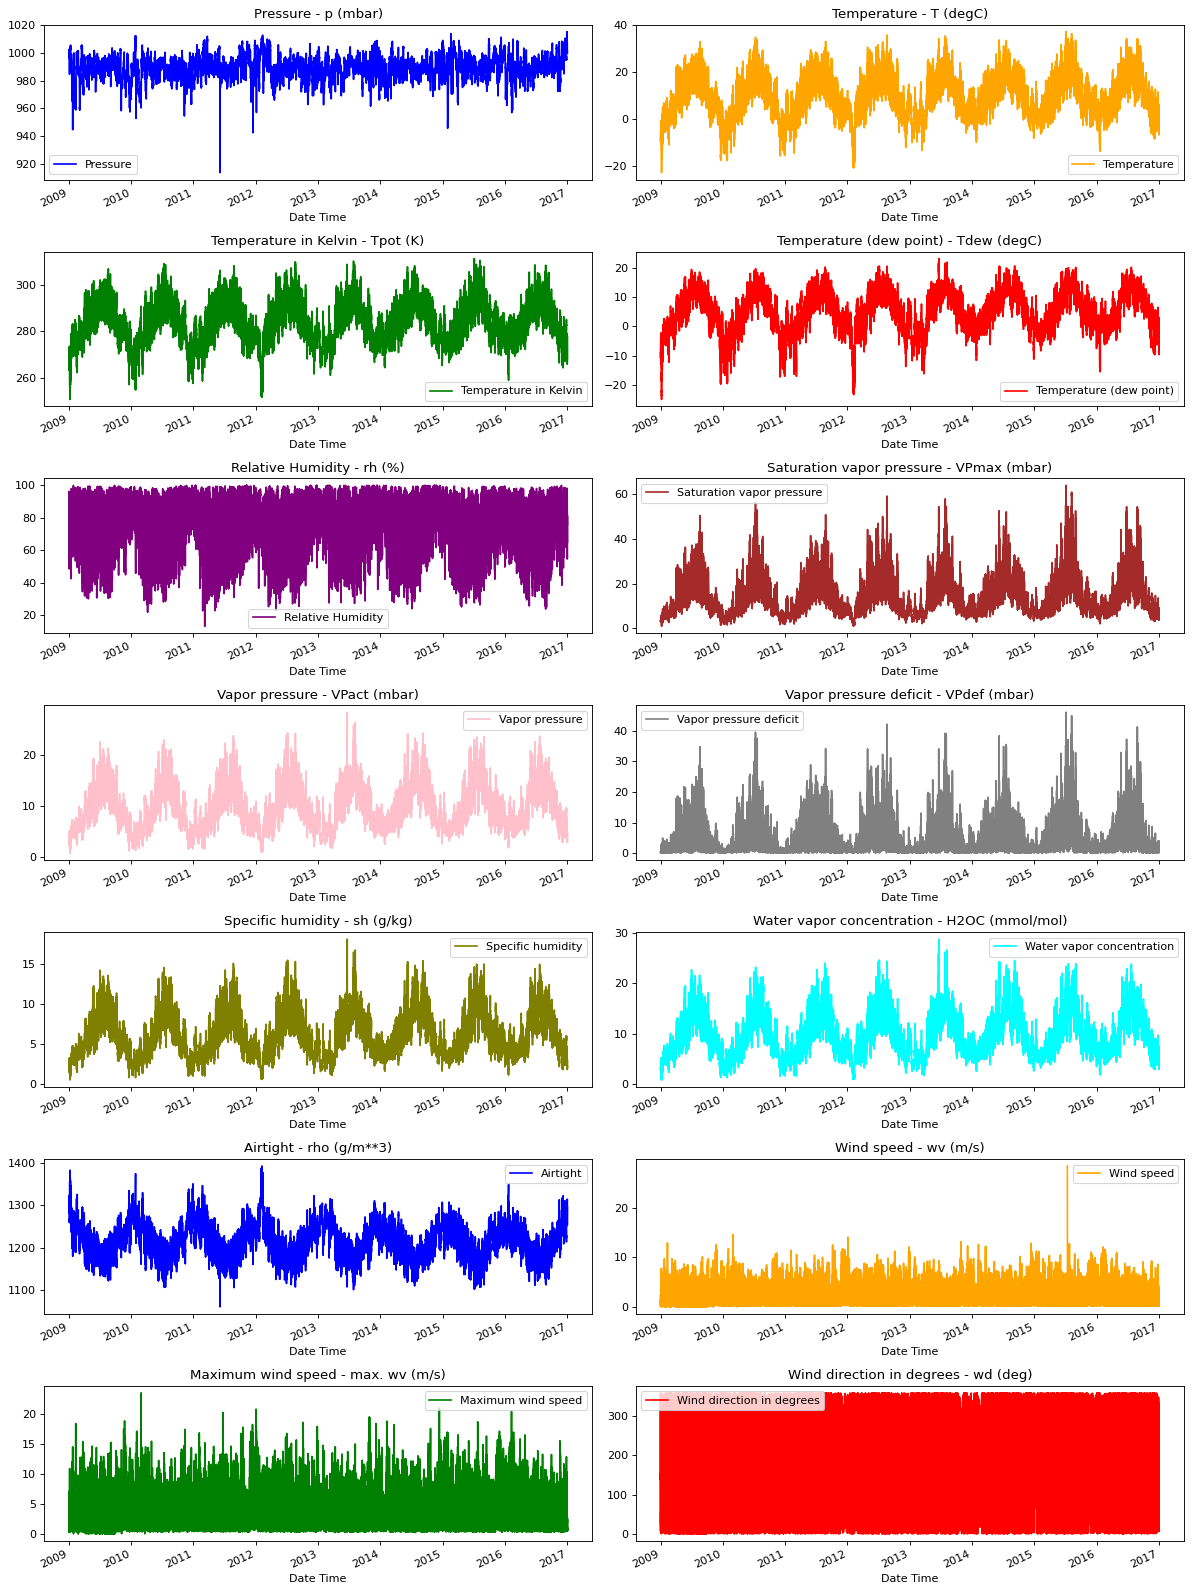

In [9]:
titles = [
    "Pressure",
    "Temperature",
    "Temperature in Kelvin",
    "Temperature (dew point)",
    "Relative Humidity",
    "Saturation vapor pressure",
    "Vapor pressure",
    "Vapor pressure deficit",
    "Specific humidity",
    "Water vapor concentration",
    "Airtight",
    "Wind speed",
    "Maximum wind speed",
    "Wind direction in degrees",
]

feature_keys = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)",
]

colors = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown",
    "pink",
    "gray",
    "olive",
    "cyan",
]

date_time_key = "Date Time"


def show_raw_visualization(data):
    time_data = data[date_time_key]
    fig, axes = plt.subplots(
        nrows=7, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k"
    )
    for i in range(len(feature_keys)):
        key = feature_keys[i]
        c = colors[i % (len(colors))]
        t_data = data[key]
        t_data.index = time_data
        t_data.head()
        ax = t_data.plot(
            ax=axes[i // 2, i % 2],
            color=c,
            title="{} - {}".format(titles[i], key),
            rot=25,
        )
        ax.legend([titles[i]])
    plt.tight_layout()


show_raw_visualization(df)


### 2.5.6 Identification of Numerical Variables

Before analysing variable distributions, all numerical features in the dataset were identified using `df.select_dtypes(include=[np.number])`. A total of 14 numerical variables were detected, corresponding to the meteorological measurements recorded by the weather station.

These variables include temperature‑related features (T, Tpot, Tdew), humidity‑related features (rh, VPact, sh, H2OC), pressure (p), wind‑related variables (wv, max. wv, wd), and other atmospheric indicators. Identifying the numerical columns ensures that subsequent statistical and distributional analyses are applied consistently across all quantitative features.

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)
print("Total numeric:", len(num_cols))

Numeric columns: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Total numeric: 14


### 2.5.7 Distribution Analysis (Histograms)

To analyse the empirical distribution of each meteorological variable, histograms were generated for all 14 numerical features in the dataset. This step helps identify skewness, multimodality, and the presence of extreme values that may influence the behaviour of forecasting models.

The histograms reveal that most variables exhibit non‑Gaussian distributions:

* Wind-related variables (wv, max. wv) show strong right‑skewness due to occasional high‑intensity wind events.
* Humidity-related variables (rh, VPact, sh, H2OC) cluster near their physical limits, reflecting atmospheric saturation behaviour.
* Temperature-related variables (T, Tpot, Tdew) display multimodal patterns associated with seasonal cycles.
* Atmospheric pressure (p) shows a narrow distribution with low variance, consistent with synoptic‑scale weather dynamics.

These findings highlight the importance of applying normalization before model training and justify the use of models capable of capturing non‑linear and non‑Gaussian patterns.

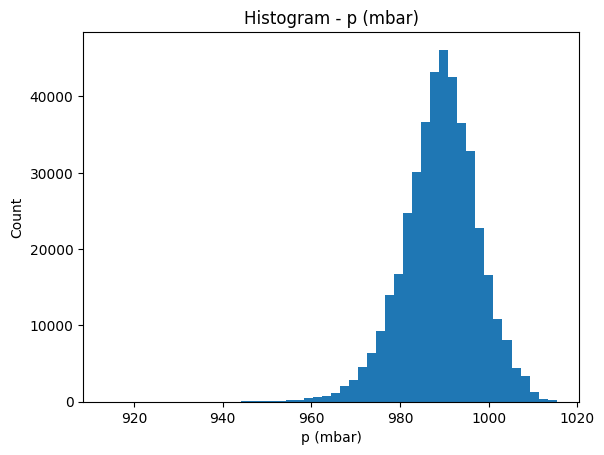

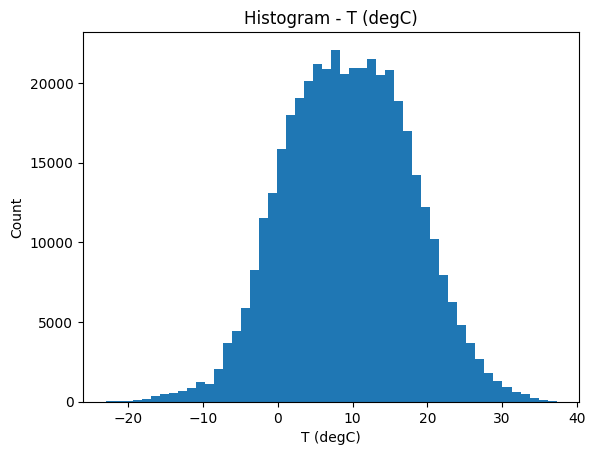

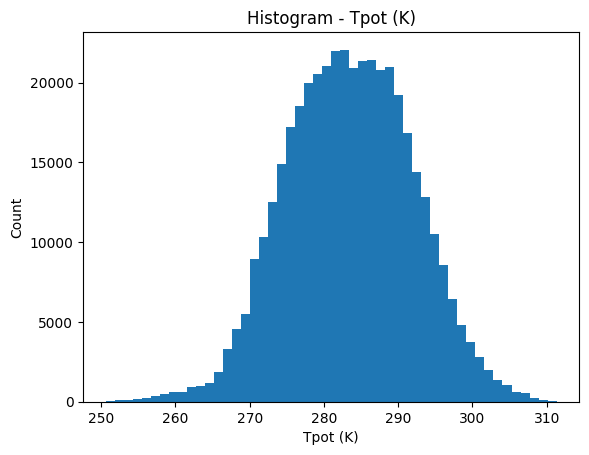

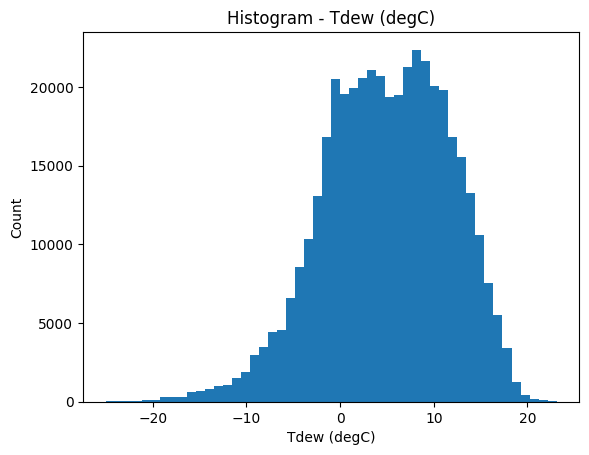

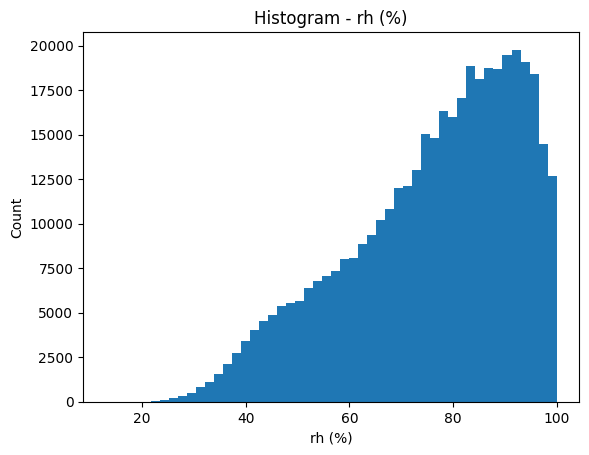

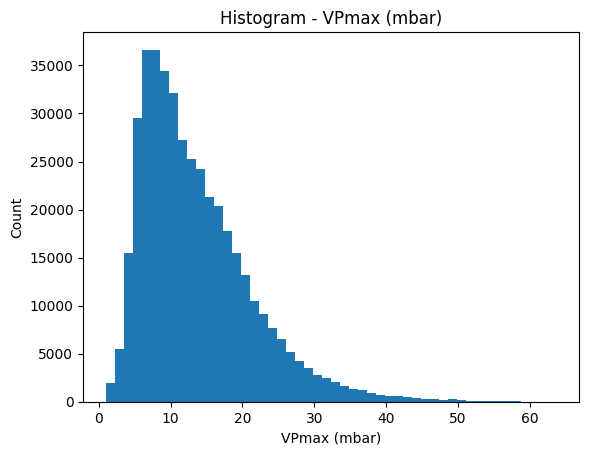

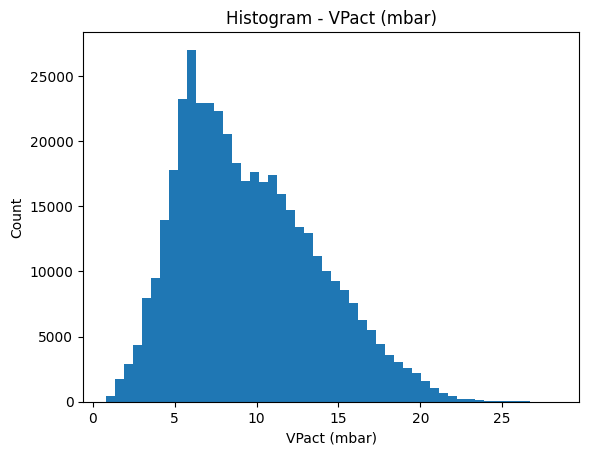

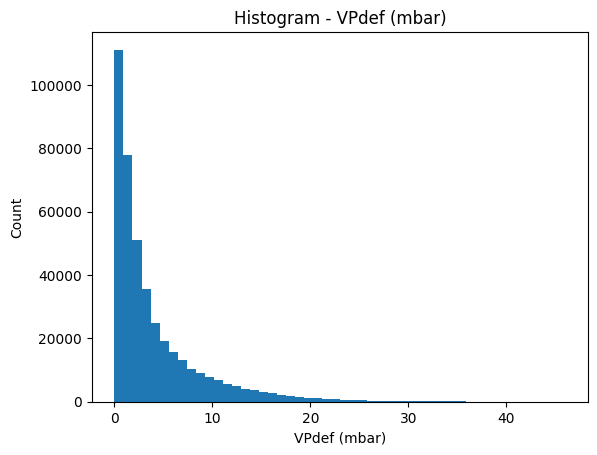

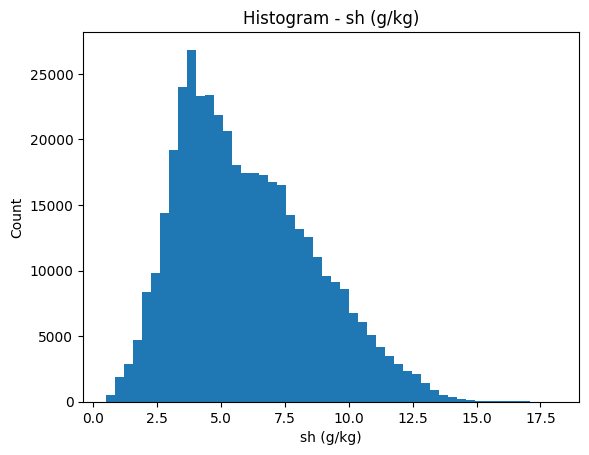

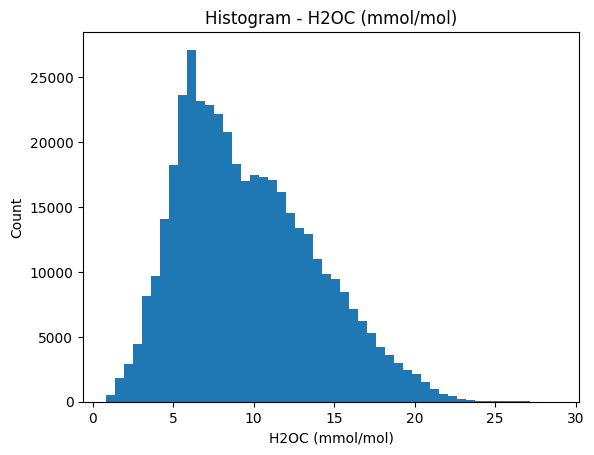

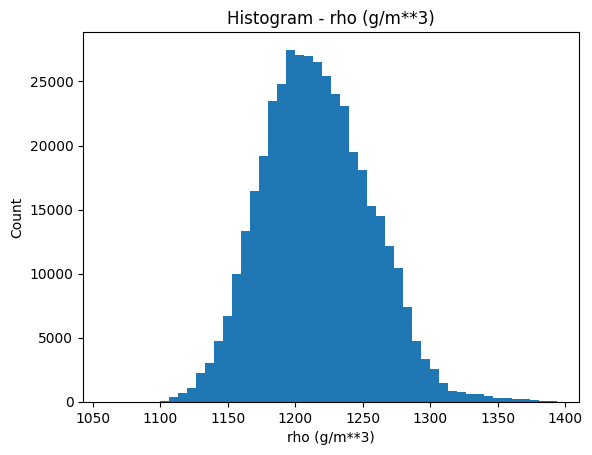

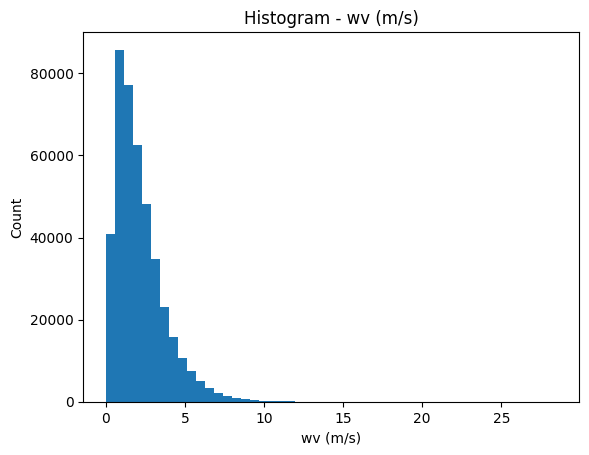

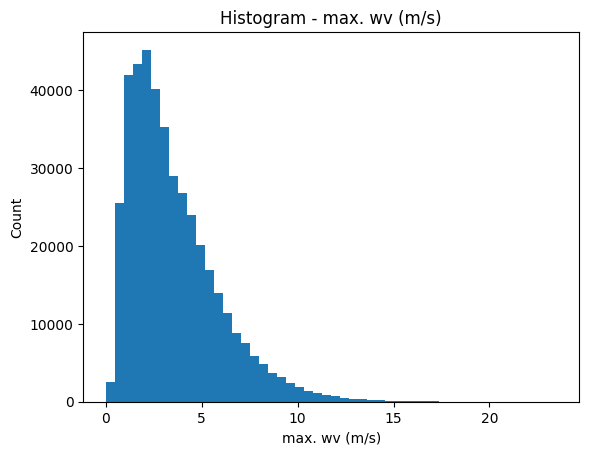

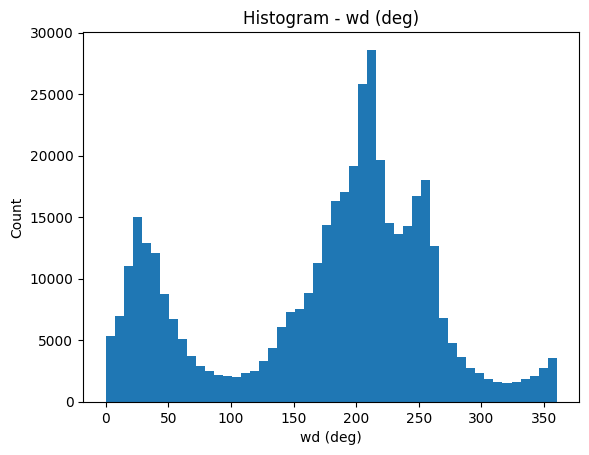

In [11]:
for c in num_cols:
    plt.figure()
    plt.hist(df[c].dropna(), bins=50)
    plt.title(f"Histogram - {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.show()

### 2.5.8 Boxplots

Boxplots were generated for all numerical variables to visualise their spread and identify potential extreme values. These plots provide a compact summary of the median, interquartile range (IQR), and outliers for each feature. Most variables exhibit a considerable number of outliers, which is expected in meteorological data due to natural variability and occasional extreme weather events. Wind‑related variables, vapor pressure deficit, and pressure show particularly wide ranges, indicating high variability in atmospheric conditions.

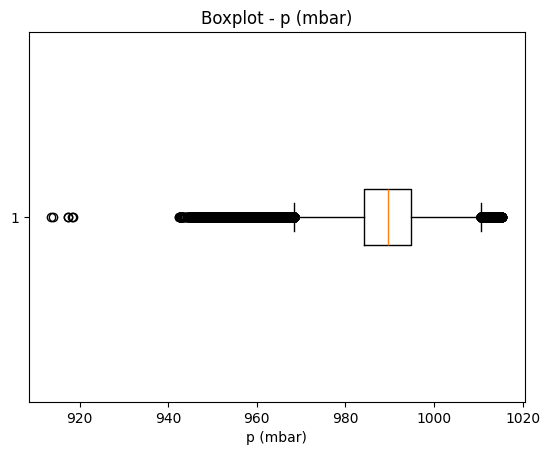

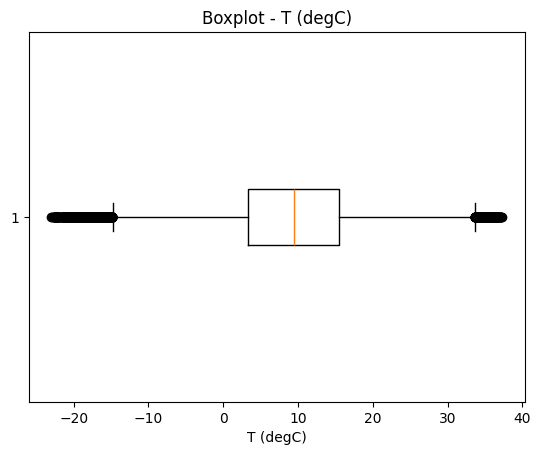

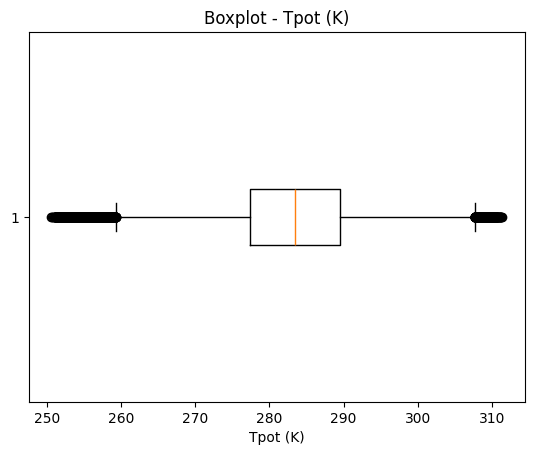

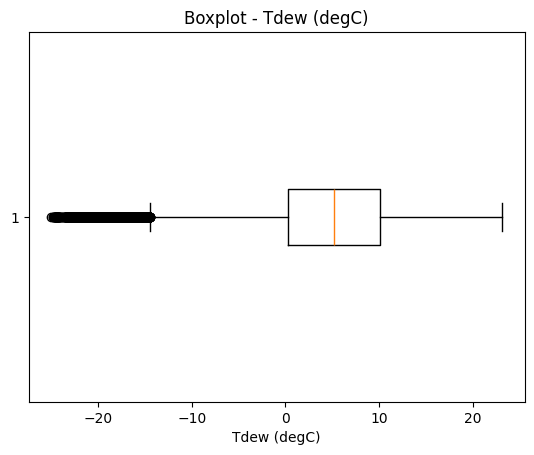

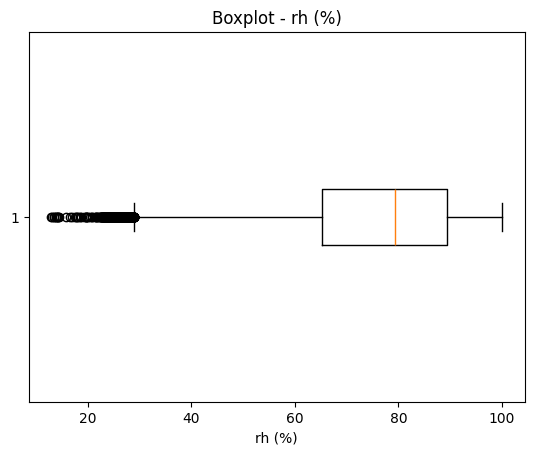

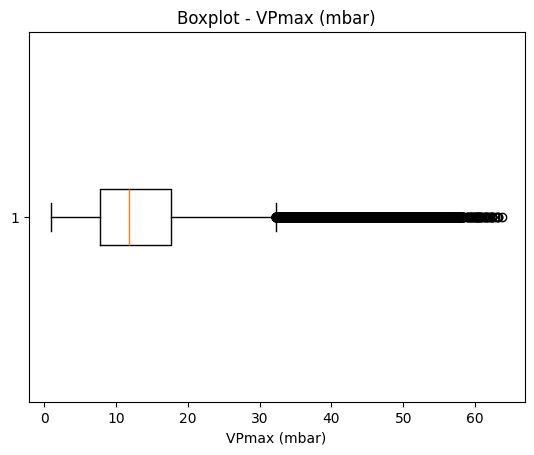

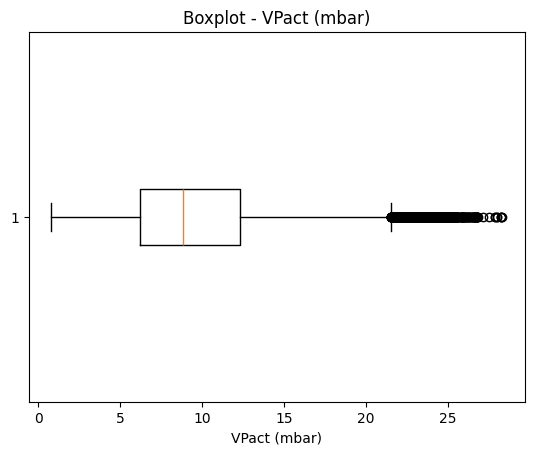

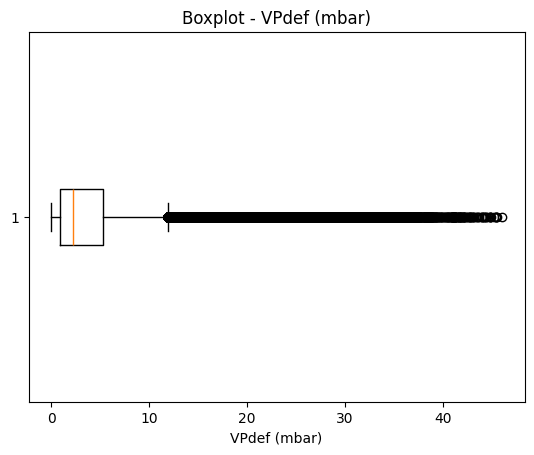

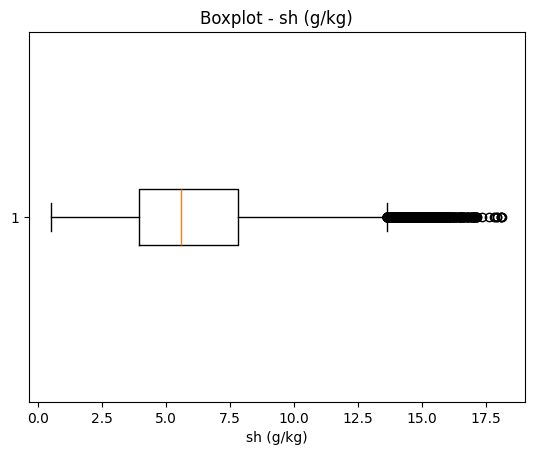

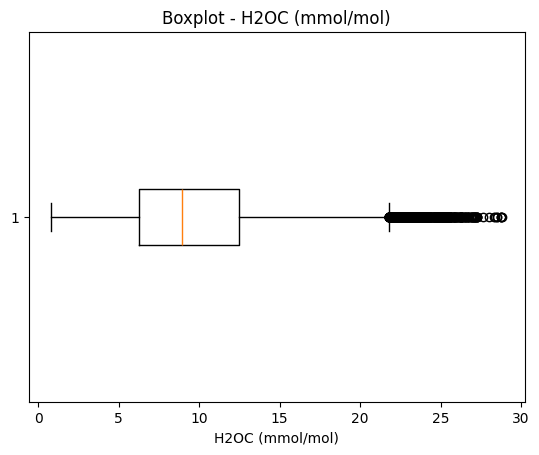

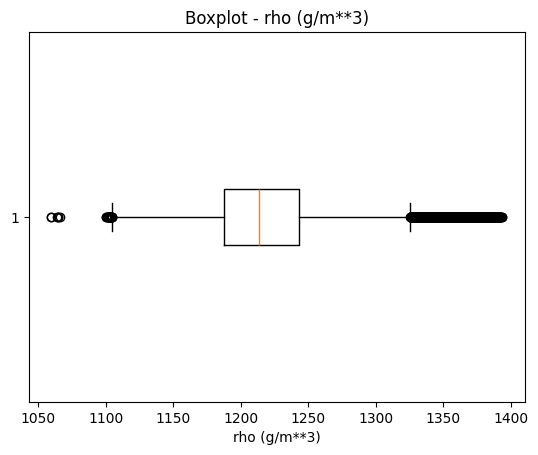

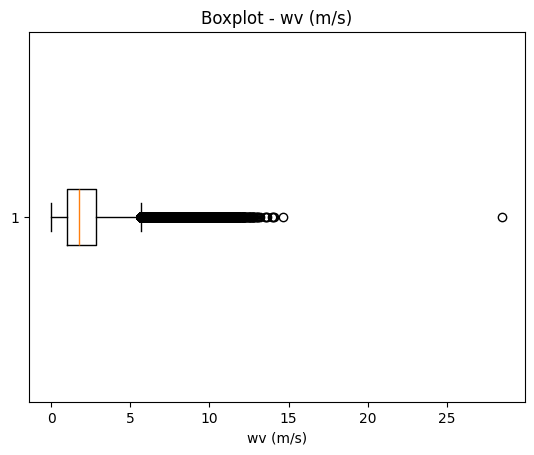

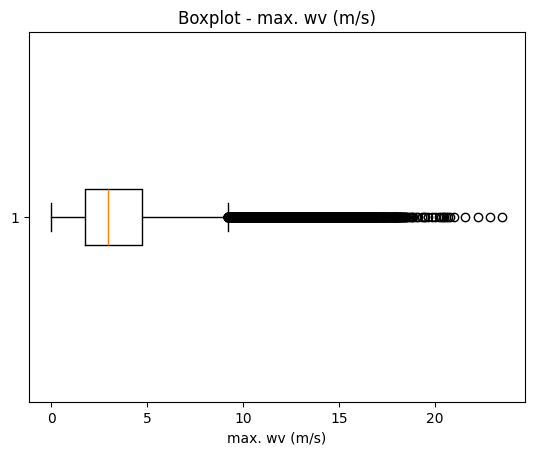

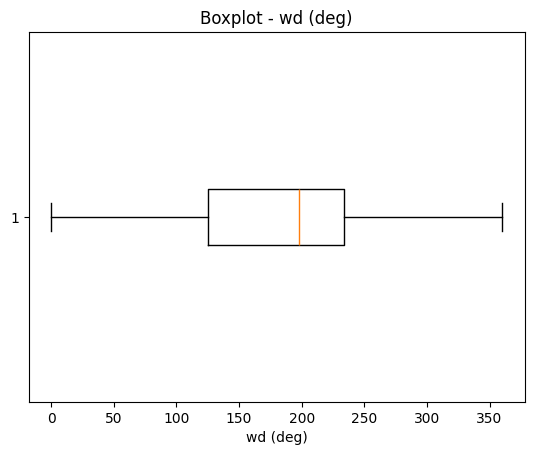

In [12]:
for c in num_cols:
    plt.figure()
    plt.boxplot(df[c].dropna(), vert=False)
    plt.title(f"Boxplot - {c}")
    plt.xlabel(c)
    plt.show()

### 2.5.9 Outlier Detection

Outliers were quantified using the Interquartile Range (IQR) method. For each numerical variable, values below Q1 − 1.5·IQR or above Q3 + 1.5·IQR were flagged as outliers.
The variables with the highest number of outliers include:

* VPdef (mbar): over 32,000 outliers  
* wv (m/s) and max. wv (m/s): more than 26,000 outliers combined  
* VPmax (mbar): over 11,000 outliers  
* p (mbar): approximately 6,700 outliers  

These extreme values represent real atmospheric phenomena (e.g., storms, rapid pressure changes), so they were retained rather than removed.

In [13]:
outlier_summary = []

for c in num_cols:
    s = df[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    outlier_summary.append([c, n_outliers, lower, upper])

outliers_df = pd.DataFrame(outlier_summary, columns=["col", "n_outliers", "iqr_low", "iqr_high"])
display(outliers_df.sort_values("n_outliers", ascending=False))

,col,n_outliers,iqr_low,iqr_high
7,VPdef (mbar),32347,-5.775,11.945
11,wv (m/s),14740,-1.815,5.665
12,max. wv (m/s),11761,-2.710,9.210
5,VPmax (mbar),11565,-6.950,32.330
0,p (mbar),6750,968.420,1010.500
10,rho (g/m**3),3048,1104.570,1325.690
3,Tdew (degC),2603,-14.505,24.815
2,Tpot (K),1945,259.280,307.680
1,T (degC),1528,-14.805,33.635
8,sh (g/kg),1439,-1.900,13.620


### 2.5.10 Correlation Between Variables

A correlation matrix was computed to analyse linear relationships between all numerical variables. The heatmap reveals several strong correlations:

* Temperature‑related variables (T, Tpot, Tdew) are highly correlated with vapor pressure and humidity variables (VPact, sh, H2OC).
* Air density (rho) is strongly negatively correlated with temperature, reflecting physical gas‑law relationships.
* Wind‑related variables show weak correlations with most other features, indicating that wind dynamics behave independently from temperature and humidity.

These correlations confirm that many variables are physically interdependent, and care must be taken to avoid redundant features during modelling.

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
p (mbar),1.000000,-0.045375,-0.124718,-0.066755,-0.018352,-0.031546,-0.054370,-0.003401,-0.069762,-0.069804,0.307640,-0.209615,-0.204801,-0.063258
T (degC),-0.045375,1.000000,0.996827,0.895708,-0.572416,0.951113,0.867673,0.761744,0.866755,0.867177,-0.963410,0.088435,0.125144,0.038732
Tpot (K),-0.124718,0.996827,1.000000,0.894911,-0.567127,0.947293,0.866205,0.756962,0.866533,0.866955,-0.981345,0.104688,0.140752,0.043599
Tdew (degC),-0.066755,0.895708,0.894911,1.000000,-0.156615,0.799271,0.968344,0.435752,0.967599,0.968044,-0.885232,-0.053624,-0.036138,0.049877
rh (%),-0.018352,-0.572416,-0.567127,-0.156615,1.000000,-0.615842,-0.151494,-0.843835,-0.150841,-0.150969,0.514282,-0.312248,-0.362965,-0.015912
VPmax (mbar),-0.031546,0.951113,0.947293,0.799271,-0.615842,1.000000,0.824865,0.875588,0.824460,0.824493,-0.901536,0.092519,0.126451,-0.009583
VPact (mbar),-0.054370,0.867673,0.866205,0.968344,-0.151494,0.824865,1.000000,0.449154,0.999851,0.999856,-0.850241,-0.068835,-0.055827,0.018418
VPdef (mbar),-0.003401,0.761744,0.756962,0.435752,-0.843835,0.875588,0.449154,1.000000,0.448641,0.448689,-0.698290,0.205034,0.247544,-0.030881
sh (g/kg),-0.069762,0.866755,0.866533,0.967599,-0.150841,0.824460,0.999851,0.448641,1.000000,0.999997,-0.853325,-0.065332,-0.052480,0.019376
H2OC (mmol/mol),-0.069804,0.867177,0.866955,0.968044,-0.150969,0.824493,0.999856,0.448689,0.999997,1.000000,-0.853769,-0.065255,-0.052371,0.019607


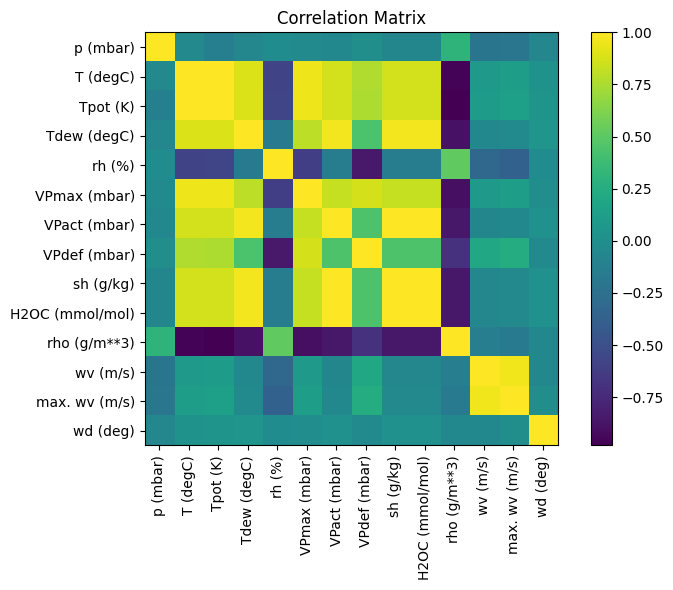

In [14]:
corr = df[num_cols].corr()

display(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr.values)
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

### 2.5.11 Correlation with Target Variable (Temperature)

To better understand which variables are most informative for forecasting temperature, the correlation of each feature with T (degC) was computed.
The strongest positive correlations include:

* Tpot (K) 
* VPmax (mbar) 
* Tdew (degC)
* VPact (mbar) 
* sh (g/kg) 
* H2OC (mmol/mol) 

Strong negative correlations include:

* rho (g/m³)
* rh (%)
* p (mbar)

Wind‑related variables show weak correlations with temperature, suggesting they contribute limited direct predictive power for this target.

T (degC)           1.000000
Tpot (K)           0.996827
VPmax (mbar)       0.951113
Tdew (degC)        0.895708
VPact (mbar)       0.867673
H2OC (mmol/mol)    0.867177
sh (g/kg)          0.866755
VPdef (mbar)       0.761744
max. wv (m/s)      0.125144
wv (m/s)           0.088435
wd (deg)           0.038732
p (mbar)          -0.045375
rh (%)            -0.572416
rho (g/m**3)      -0.963410
Name: T (degC), dtype: float64

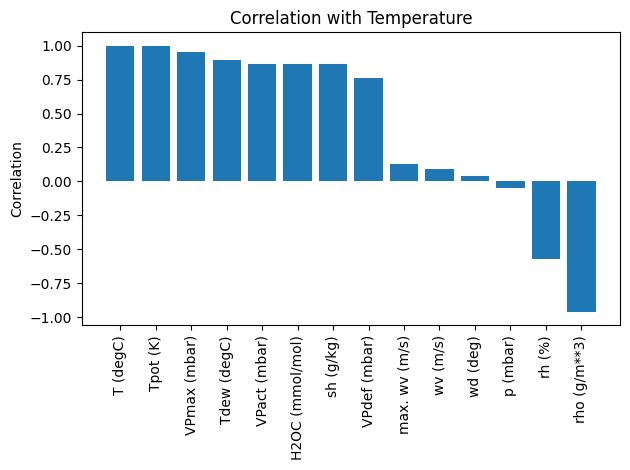

In [15]:
target = "T (degC)"
corr_target = corr[target].sort_values(ascending=False)

display(corr_target)

plt.figure()
plt.bar(corr_target.index, corr_target.values)
plt.xticks(rotation=90)
plt.title("Correlation with Temperature")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

### 2.5.12 Temporal Evolution of Temperature

A time‑series plot of temperature from 2009 to 2017 reveals clear seasonal cycles, with warm summers and cold winters repeating annually. Short‑term fluctuations correspond to daily and synoptic‑scale weather variations.

This long‑term structure confirms that the dataset contains strong periodic components, which must be captured by the forecasting model.

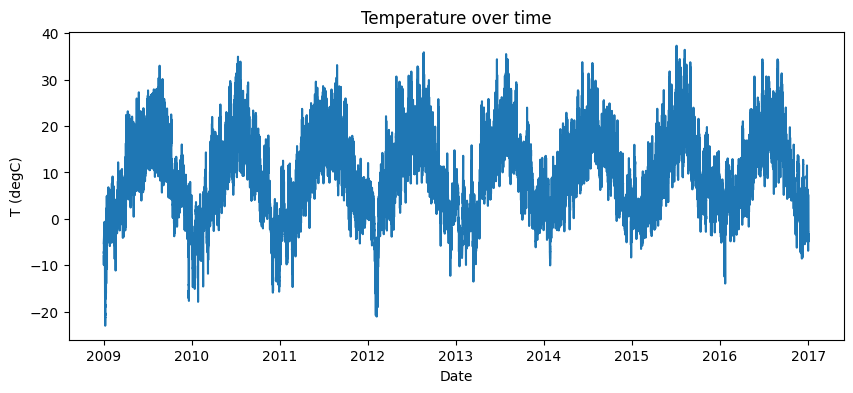

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(df["Date Time"], df["T (degC)"])
plt.title("Temperature over time")
plt.xlabel("Date")
plt.ylabel("T (degC)")
plt.show()

### 2.5.13 Mean Temperature by Hour of Day

To analyse diurnal patterns, the average temperature was computed for each hour of the day. The resulting profile shows a typical daily cycle:

* Minimum temperatures occur during the early morning hours.
* Temperatures rise sharply after sunrise.
* Peak temperatures occur in the mid‑afternoon.
* Cooling begins after sunset.

This confirms the presence of strong daily periodicity, which is relevant for short‑term forecasting.

In [17]:
# Strip any accidental whitespace from column names (defensive, no-op if already clean)
df.columns = df.columns.str.strip()

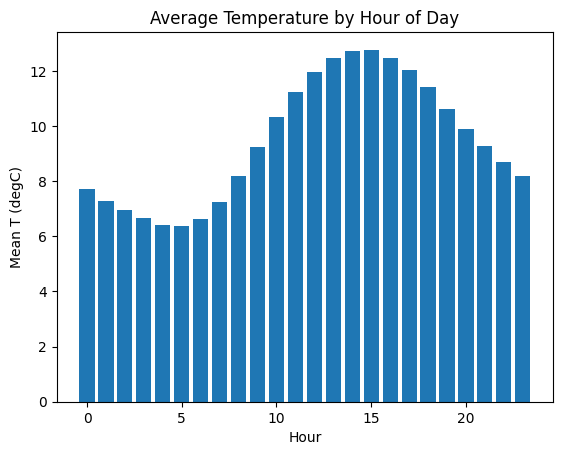

In [18]:
df["hour"] = df["Date Time"].dt.hour
hourly_mean = df.groupby("hour")["T (degC)"].mean()

plt.figure()
plt.bar(hourly_mean.index, hourly_mean.values)
plt.title("Average Temperature by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Mean T (degC)")
plt.show()

### 2.5.14 Annual Seasonality

To analyse long‑term seasonal behaviour, the average temperature was computed for each month of the year. The results show a clear annual cycle, with minimum temperatures occurring in winter (January and December) and maximum temperatures during summer (July and August). This confirms the presence of strong yearly seasonality in the dataset, which is relevant for medium‑ and long‑term forecasting.


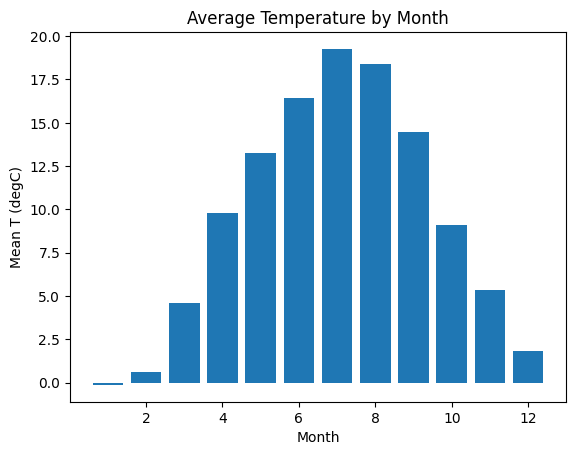

In [19]:
df["month"] = df["Date Time"].dt.month
monthly_mean = df.groupby("month")["T (degC)"].mean()

plt.figure()
plt.bar(monthly_mean.index, monthly_mean.values)
plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Mean T (degC)")
plt.show()

### 2.5.15 Target Relation with Other Variables

Scatter plots were generated to visualise the relationship between the target variable, T (degC), and each of the remaining numerical features. These plots help identify linearity, non‑linearity, and the overall structure of the relationships.

Strong linear relationships were observed with variables such as Tpot (K), Tdew (degC) and VPmax (mbar). Air density (rho) shows a strong negative relationship with temperature, consistent with physical gas‑law behaviour. Wind‑related variables display more diffuse patterns, indicating weaker direct influence on the target.

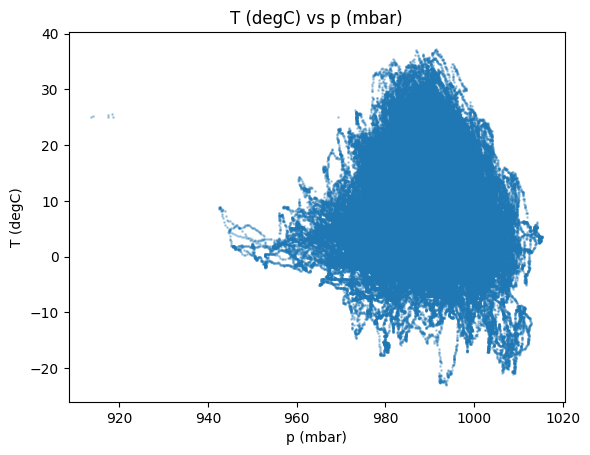

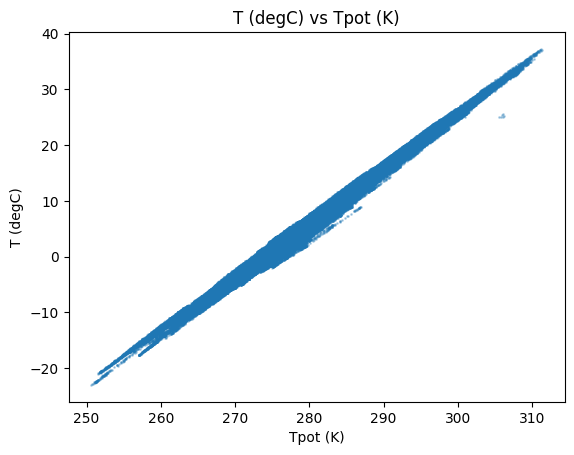

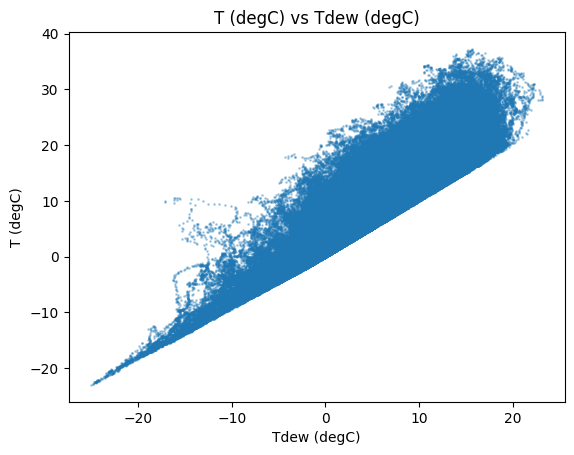

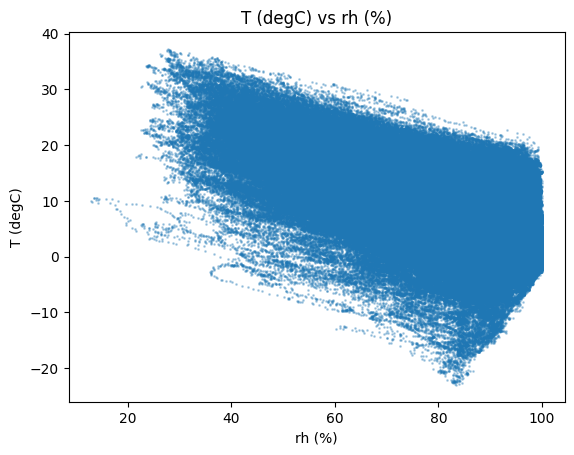

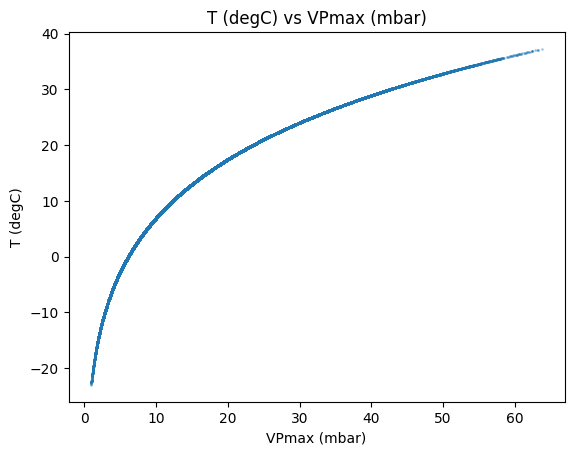

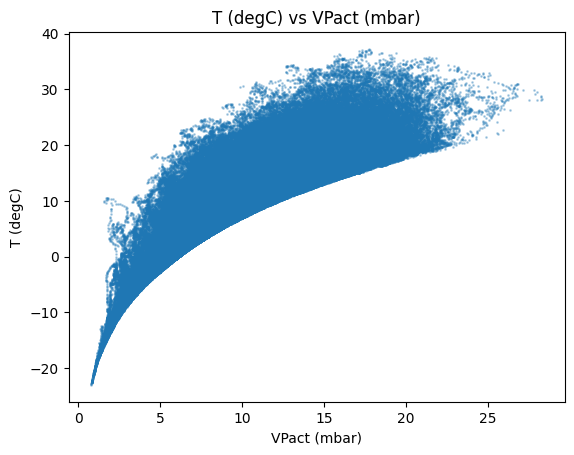

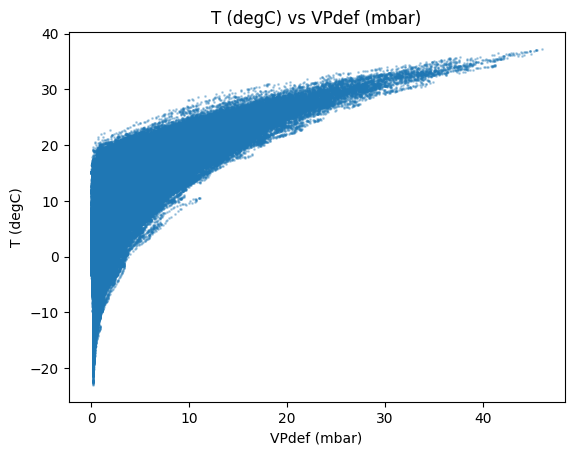

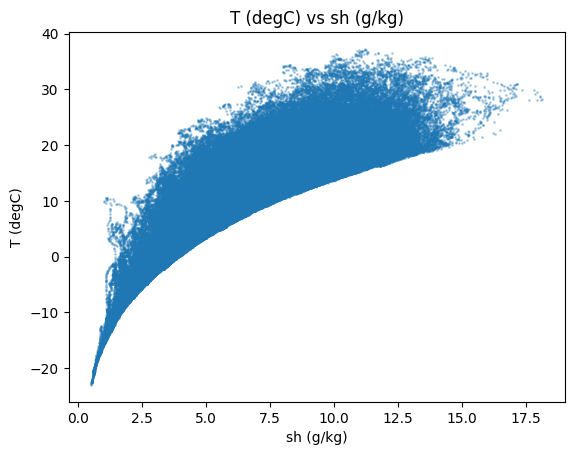

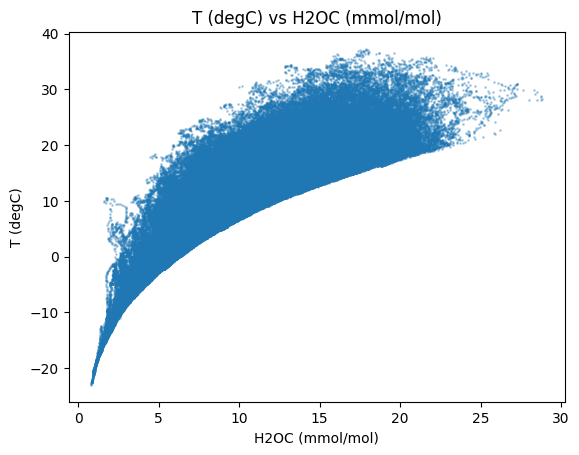

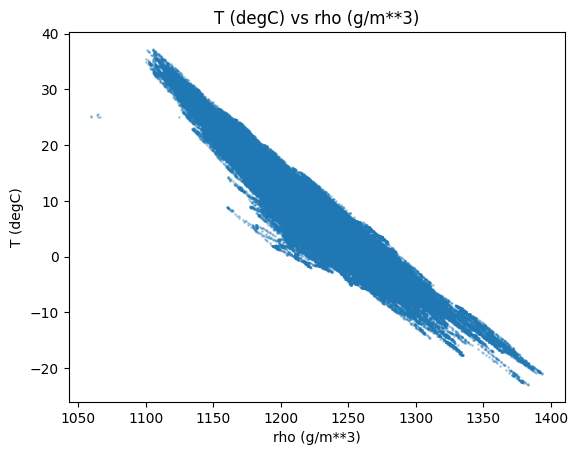

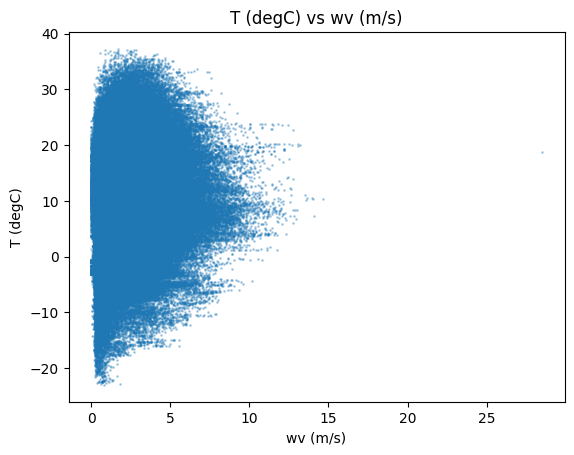

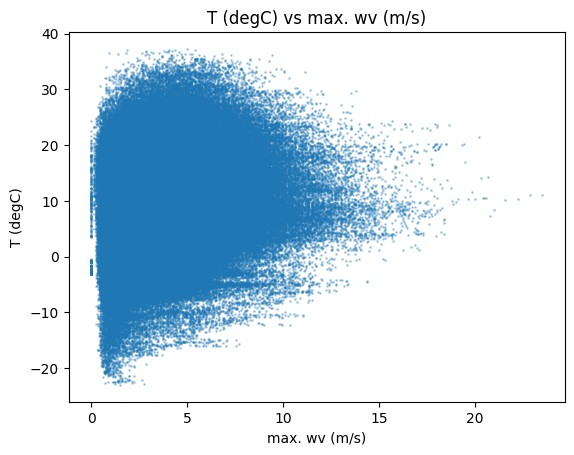

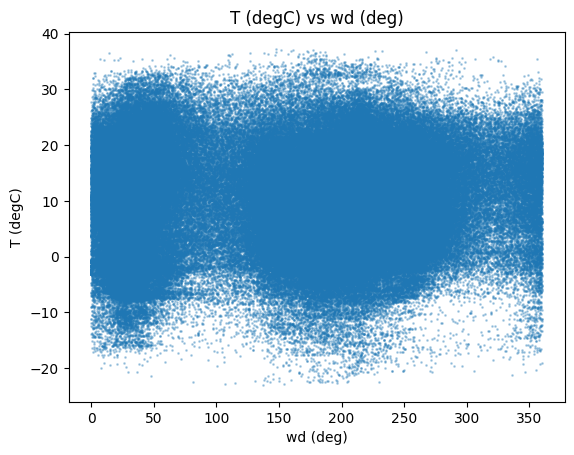

In [20]:
target = "T (degC)"
exclude = {target, "hour", "month"}
x_cols = [c for c in num_cols if c not in exclude]

for x in x_cols:
    plt.figure()
    plt.scatter(df[x], df[target], s=1, alpha=0.3)
    plt.xlabel(x)
    plt.ylabel(target)
    plt.title(f"{target} vs {x}")
    plt.show()

### 2.5.16 Target Mean Across Binned Variables

To explore potential non‑linear effects, each numerical variable was divided into a fixed number of bins, and the mean temperature was computed within each bin. This analysis highlights how the expected value of the target changes across the range of each predictor.

Variables strongly correlated with temperature (e.g., Tpot, VPmax, Tdew) show smooth and monotonic trends across bins. In contrast, wind‑related variables and some humidity measures exhibit more irregular profiles, suggesting weaker or more complex relationships with the target.

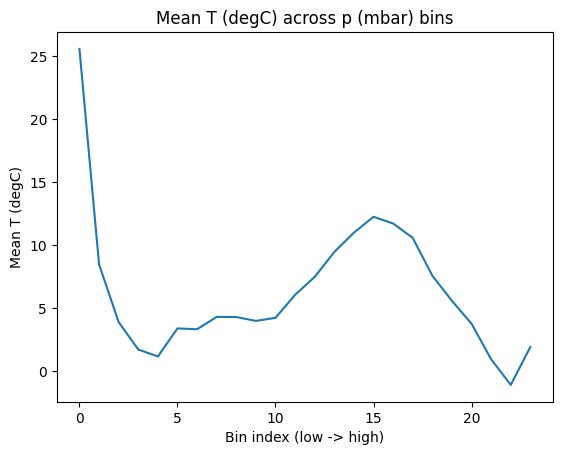

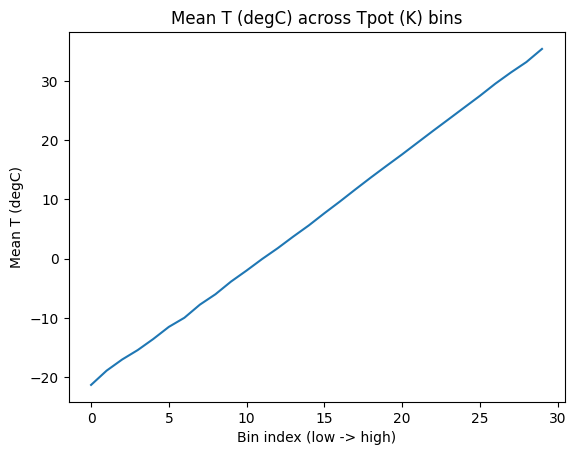

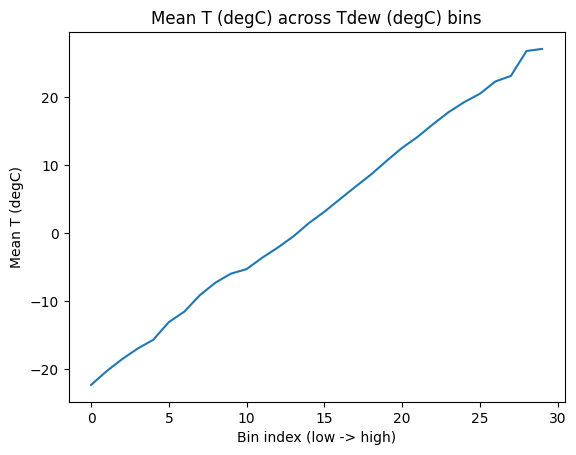

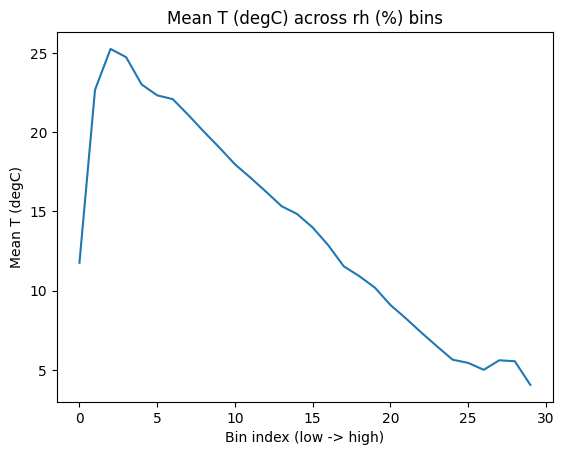

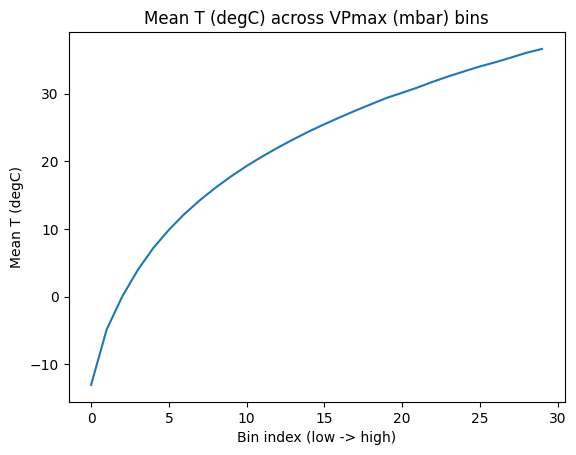

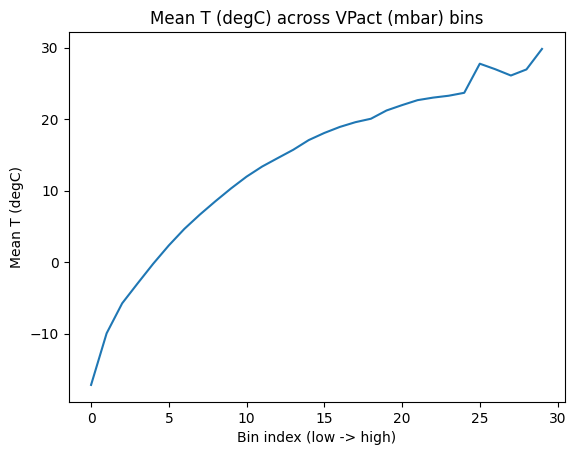

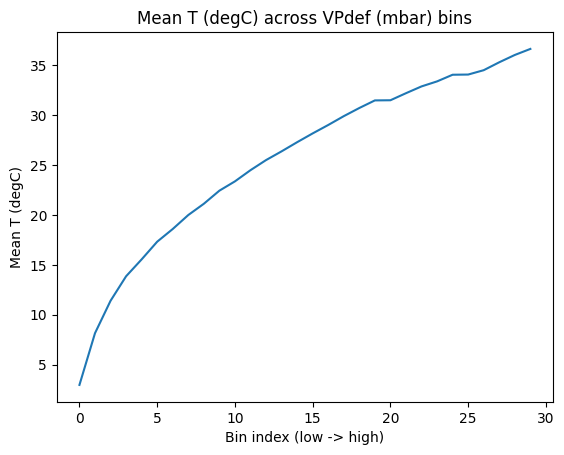

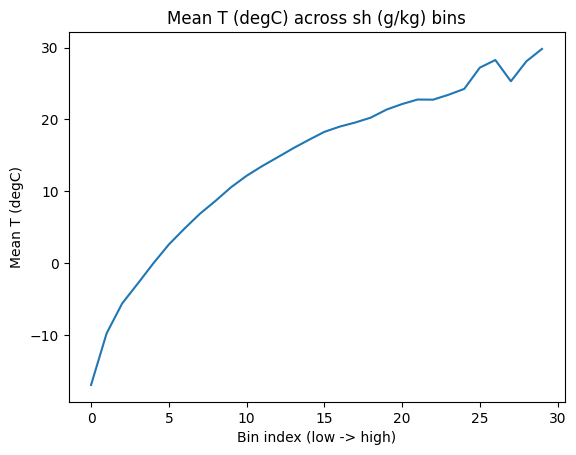

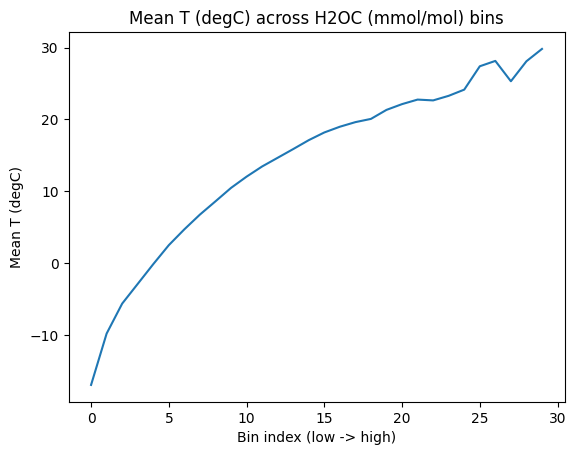

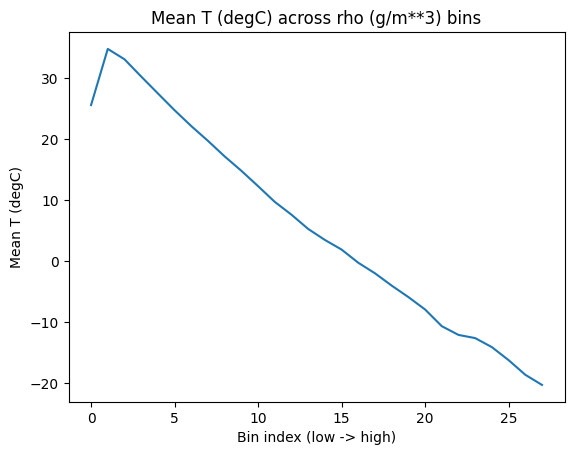

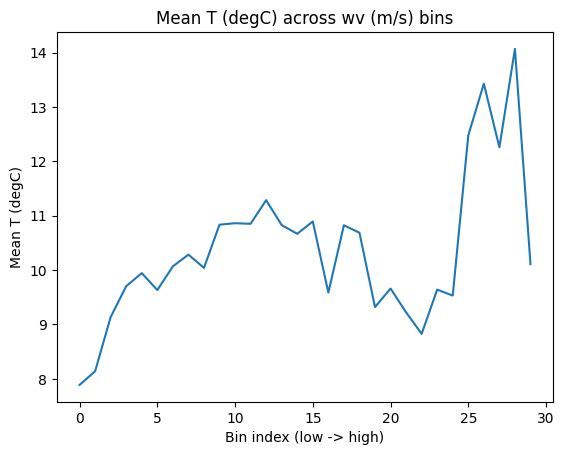

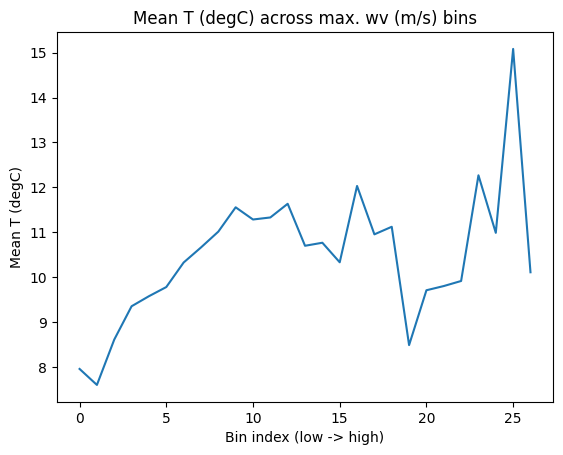

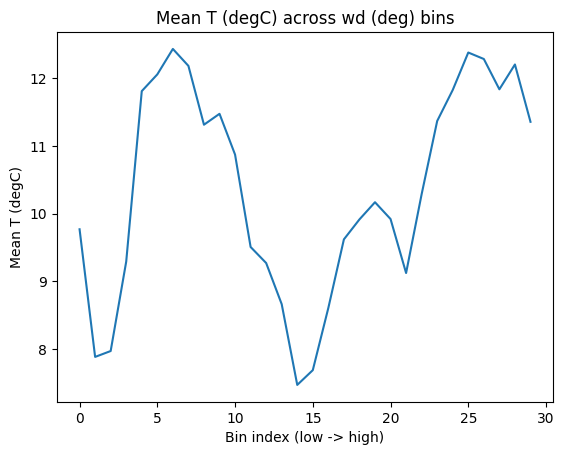

In [21]:
target = "T (degC)"
exclude = {target, "hour", "month"}
x_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]

df_s = df.sample(50000, random_state=42)

for x in x_cols:
    # dividir x em 30 intervalos e ver média de T em cada intervalo
    bins = pd.cut(df_s[x], bins=30)
    m = df_s.groupby(bins)[target].mean()

    plt.figure()
    plt.plot(range(len(m)), m.values)
    plt.title(f"Mean {target} across {x} bins")
    plt.xlabel("Bin index (low -> high)")
    plt.ylabel(f"Mean {target}")
    plt.show()

### 2.5.17 Variables Mean by Hour of Day

The mean value of selected variables (temperature, relative humidity, pressure and wind speed) was computed for each hour of the day to characterise diurnal patterns.

Temperature follows a typical daily cycle, with minimum values in the early morning and maximum values in the mid‑afternoon. Relative humidity shows the opposite behaviour, peaking around dawn and decreasing throughout the day. Pressure and wind speed also exhibit systematic daily variations, although with smaller amplitude. These results confirm the presence of strong intra‑day seasonality in the dataset.


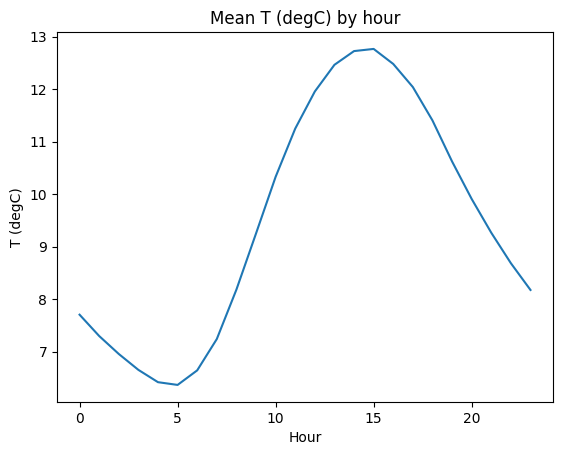

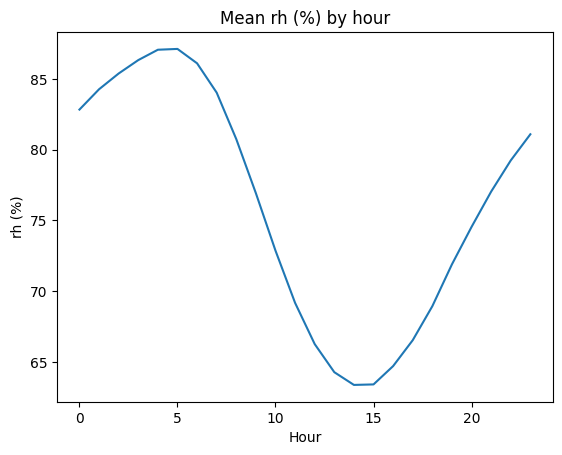

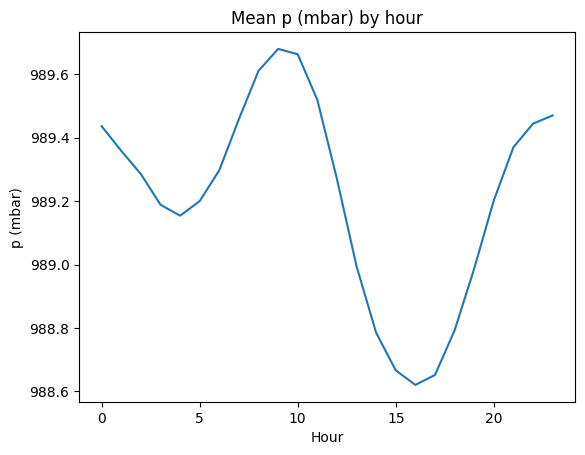

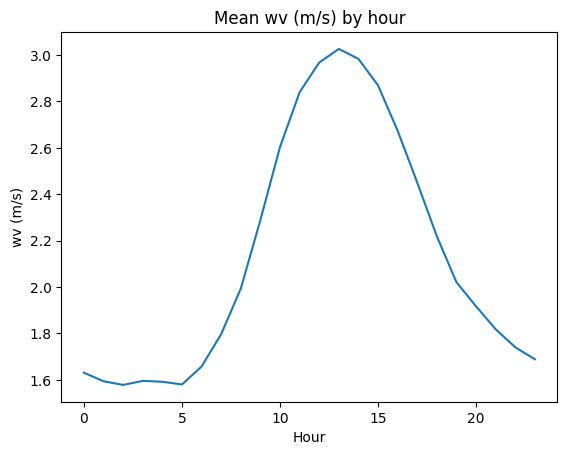

In [22]:
df["hour"] = df["Date Time"].dt.hour

vars_to_check = ["T (degC)", "rh (%)", "p (mbar)", "wv (m/s)"]
for v in vars_to_check:
    m = df.groupby("hour")[v].mean()
    plt.figure()
    plt.plot(m.index, m.values)
    plt.title(f"Mean {v} by hour")
    plt.xlabel("Hour")
    plt.ylabel(v)
    plt.show()

# 4. Data Understanding – Detailed Analysis

This section provides a more detailed analysis of the temporal structure and statistical properties of the dataset, focusing on aspects that directly impact time‑series modelling. The data are first sorted chronologically by the `Date Time` column, and the target variable is defined as the air temperature in degrees Celsius, `T (degC)`. The following subsections examine temporal regularity, seasonality, resampling effects, and the presence of missing values in the time series.


In [23]:
df = df.sort_values("Date Time").reset_index(drop=True)

target = "T (degC)"

## 4.1 Temporal Regularity and Gaps

To assess the temporal consistency of the dataset, the time differences between consecutive observations were computed. The most common interval is 10 minutes, confirming that the dataset follows a regular 10‑minute sampling frequency.

A small number of irregular intervals were detected, including gaps of 20 minutes and rare gaps of 2 hours. These gaps represent missing sensor readings rather than structural issues in the dataset. Identifying these irregularities is essential before resampling or applying time‑series models that assume uniform spacing.

In [24]:
# Check time deltas (frequency and gaps)
deltas = df["Date Time"].diff().dropna()
print("Most common deltas:")
display(deltas.value_counts().head(5))

mode_delta = deltas.value_counts().idxmax()
print("Mode delta:", mode_delta)

# Count gaps larger than the expected frequency
gaps = deltas[deltas > mode_delta]
print("Number of gaps larger than mode delta:", len(gaps))

# Show a few gaps (if any)
if len(gaps) > 0:
    idx = gaps.index[:10]
    display(df.loc[idx, ["Date Time"]].assign(delta=gaps.loc[idx].values))

Most common deltas:


Date Time
0 days 00:10:00    420218
0 days 00:00:00       327
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
Name: count, dtype: int64

Mode delta: 0 days 00:10:00
Number of gaps larger than mode delta: 5


,Date Time,delta
40378,2009-10-08 10:10:00,0 days 00:30:00
230019,2013-05-16 09:10:00,0 days 00:20:00
293556,2014-07-30 08:20:00,0 days 00:20:00
301673,2014-09-25 09:00:00,0 days 16:00:00
411267,2016-10-28 12:50:00,3 days 02:20:00


## 4.2 Seasonal Patterns

To better characterise the temporal dynamics of the dataset, seasonal patterns at different time scales are analysed. First, rolling statistics are used to assess the stationarity of the temperature series over a 7‑day window. Then, a preview of hourly resampling is performed to evaluate how aggregating 10‑minute measurements into hourly means affects the structure of the data. These analyses help to understand the dominant seasonal components and guide the choice of an appropriate modelling strategy.


### 4.2.1 Stationarity (Rolling Mean and Standard Deviation)

A rolling window of 7 days was applied to the temperature series to compute the rolling mean and standard deviation. The results show clear long‑term seasonal fluctuations, with both the mean and variability changing significantly throughout the year.

These patterns indicate that the temperature series is non‑stationary, exhibiting strong seasonality and long‑term trends. This reinforces the need for appropriate preprocessing steps such as normalization, detrending, or the use of models capable of handling non‑stationary behaviour.

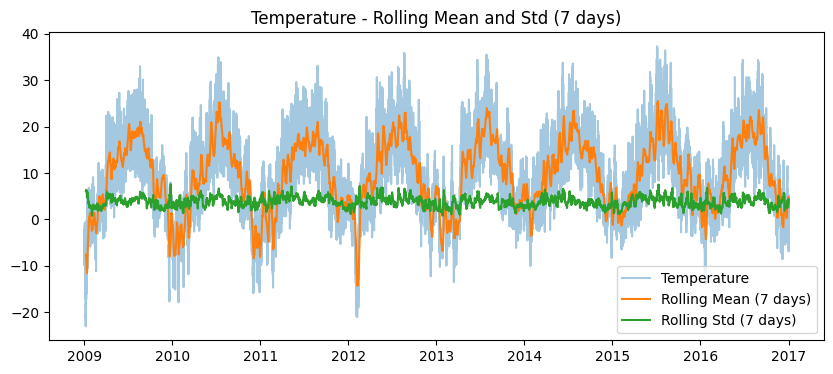

In [25]:
# Rolling mean and std for temperature (7-day window)
w = 7 * 24 * 6  # 7 days with 10-min data
t = df.set_index("Date Time")["T (degC)"]

roll_mean = t.rolling(w).mean()
roll_std = t.rolling(w).std()

plt.figure(figsize=(10, 4))
plt.plot(t, alpha=0.4, label="Temperature")
plt.plot(roll_mean, label="Rolling Mean (7 days)")
plt.plot(roll_std, label="Rolling Std (7 days)")
plt.title("Temperature - Rolling Mean and Std (7 days)")
plt.legend()
plt.show()

### 4.2.2 Preview of Hourly Resampling

The dataset was resampled to an hourly frequency using the mean of all measurements within each hour. The resulting hourly dataset contains 70,129 rows and preserves the overall structure of the original data while reducing noise and redundancy.

A check for missing timestamps confirmed that no hourly timestamps are missing. However, 88 NaN values were found in each variable, corresponding to hours where no valid observations were available. These missing rows must be handled before model training.


In [26]:
feature_keys = [
    "p (mbar)", "T (degC)", "Tpot (K)", "Tdew (degC)", "rh (%)",
    "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "sh (g/kg)",
    "H2OC (mmol/mol)", "rho (g/m**3)", "wv (m/s)", "max. wv (m/s)", "wd (deg)"
]

df_hourly = (
    df.set_index("Date Time")[feature_keys]
      .resample("1h")   # <- lowercase h
      .mean()
      .reset_index()
)

print("Hourly shape:", df_hourly.shape)
display(df_hourly.head())

Hourly shape: (70129, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


In [27]:
print("Hourly missing timestamps:", df_hourly["Date Time"].isna().sum())
print("NaNs per column (hourly):")
display(df_hourly.isna().sum())

Hourly missing timestamps: 0
NaNs per column (hourly):


Date Time           0
p (mbar)           88
T (degC)           88
Tpot (K)           88
Tdew (degC)        88
rh (%)             88
VPmax (mbar)       88
VPact (mbar)       88
VPdef (mbar)       88
sh (g/kg)          88
H2OC (mmol/mol)    88
rho (g/m**3)       88
wv (m/s)           90
max. wv (m/s)      91
wd (deg)           88
dtype: int64

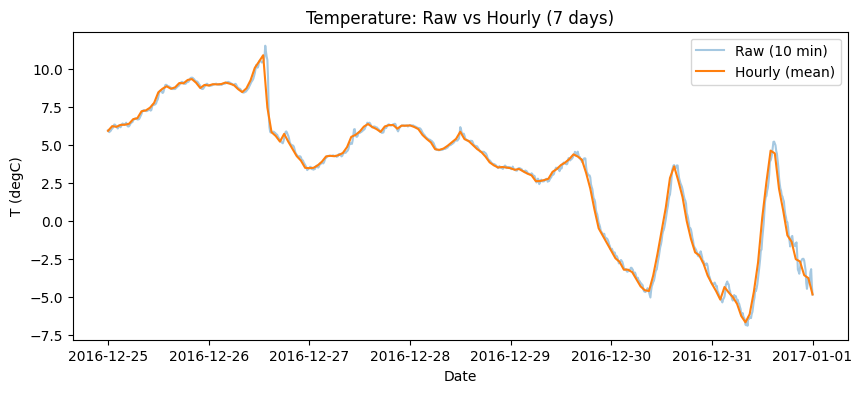

In [28]:
end = df["Date Time"].max()
start = end - pd.Timedelta(days=7)

raw_7d = df[(df["Date Time"] >= start) & (df["Date Time"] <= end)]
hourly_7d = df_hourly[(df_hourly["Date Time"] >= start) & (df_hourly["Date Time"] <= end)]

plt.figure(figsize=(10, 4))
plt.plot(raw_7d["Date Time"], raw_7d["T (degC)"], alpha=0.4, label="Raw (10 min)")
plt.plot(hourly_7d["Date Time"], hourly_7d["T (degC)"], label="Hourly (mean)")
plt.title("Temperature: Raw vs Hourly (7 days)")
plt.xlabel("Date")
plt.ylabel("T (degC)")
plt.legend()
plt.show()

## 4.3 Identification of Missing Hourly Observations

Rows containing missing values in the hourly dataset were identified. A total of 91 hourly rows contain NaNs across all variables, typically corresponding to periods where the original 10‑minute data had gaps.

These missing rows occur in contiguous blocks, indicating intervals where the weather station did not record any measurements. Since these rows contain no usable information, they must be removed or imputed before further analysis.


In [29]:
na_rows = df_hourly[df_hourly.isna().any(axis=1)].copy()
print("Hourly rows with NaN:", len(na_rows))
display(na_rows.head(10))
display(na_rows.tail(10))

Hourly rows with NaN: 91


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
50226,2014-09-24 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50227,2014-09-24 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50228,2014-09-24 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50229,2014-09-24 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50230,2014-09-24 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50231,2014-09-24 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50232,2014-09-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50233,2014-09-25 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50234,2014-09-25 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50235,2014-09-25 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
68570,2016-10-28 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68571,2016-10-28 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68572,2016-10-28 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68573,2016-10-28 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68574,2016-10-28 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68575,2016-10-28 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68576,2016-10-28 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68577,2016-10-28 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68578,2016-10-28 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68579,2016-10-28 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.3.1 Removal of Missing Hourly Rows

To ensure data consistency, all hourly rows containing NaN values were removed. This reduced the dataset from 70,129 to 70,038 rows. A final check confirmed that no missing values remain in the cleaned hourly dataset.

This cleaned version of the hourly data will be used for subsequent modelling steps.

In [30]:
# Clean hourly data by dropping hours with no observations
df_hourly_clean = df_hourly.dropna().reset_index(drop=True)

print("Hourly before cleaning:", df_hourly.shape)
print("Hourly after cleaning: ", df_hourly_clean.shape)

# Sanity check
print("Remaining NaNs:", df_hourly_clean.isna().sum().sum())

Hourly before cleaning: (70129, 15)
Hourly after cleaning:  (70038, 15)
Remaining NaNs: 0


# 5. Data Preparation

This section describes the steps required to prepare the dataset for modelling. The process includes selecting the relevant variables, confirming data integrity, defining the temporal frequency, setting the datetime index, splitting the data into training, validation and test sets, engineering additional time‑based features, scaling the inputs, and finally constructing sliding windows for supervised learning.


## 5.1 Dataset Scope and Columns

The target variable selected for forecasting is T (degC). A subset of meteorological variables was chosen as input features, following the standard Jena Climate configuration. A clean hourly‑resampled dataset was used as the working base for all subsequent modelling steps.

### 5.1.1 Define Target, Inputs and Frequency

The target variable is defined as the hourly temperature in degrees Celsius. The input features include pressure, relative humidity, wind speed, maximum wind speed and wind direction. These variables are extracted from the cleaned hourly dataset to form the modelling dataframe. This ensures that all features share the same temporal resolution and contain no missing values.


In [31]:
# Target variable
target_col = "T (degC)"

# Input features (Jena standard set)
feature_keys = ["T (degC)", "p (mbar)", "rh (%)", "wv (m/s)", "max. wv (m/s)", "wd (deg)"]

# Final working dataframe (hourly, clean)
df_work = df_hourly_clean[["Date Time"] + feature_keys].copy()

print("df_work shape:", df_work.shape)
display(df_work.head())

df_work shape: (70038, 7)


,Date Time,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333


### 5.1.2 Sanity Checks

A validation step was performed to ensure that the working dataset contains no missing values and that all columns have the correct data types. All variables were confirmed to be numerical, and the datetime column was correctly stored as a `DatetimeIndex`. These checks guarantee that the dataset is ready for temporal indexing and model training.

In [32]:
print("NaNs per column:")
display(df_work.isna().sum())

print("\nDtypes:")
display(df_work.dtypes)

NaNs per column:


Date Time        0
T (degC)         0
p (mbar)         0
rh (%)           0
wv (m/s)         0
max. wv (m/s)    0
wd (deg)         0
dtype: int64


Dtypes:


Date Time        datetime64[us]
T (degC)                float64
p (mbar)                float64
rh (%)                  float64
wv (m/s)                float64
max. wv (m/s)           float64
wd (deg)                float64
dtype: object

### 5.1.3 Confirm Frequency is Hourly

The time differences between consecutive observations were computed to verify the sampling frequency. The most common interval is exactly 1 hour, confirming that the resampling process was successful and that the dataset is uniformly spaced in time. A uniform frequency is essential for constructing sliding windows and training sequence models.

In [33]:
# Check time delta between consecutive rows
deltas = df_work["Date Time"].diff().dropna()
print("Most common deltas:")
display(deltas.value_counts().head(3))

Most common deltas:


Date Time
0 days 01:00:00    70034
0 days 16:00:00        1
0 days 04:00:00        1
Name: count, dtype: int64

### 5.1.4 Set Date Time as Index

The `Date Time` column was set as the dataframe index, converting it into a `DatetimeIndex`. This enables efficient slicing, alignment, resampling and windowing operations, which are fundamental for time‑series forecasting workflows.

In [34]:
df_work = df_work.set_index("Date Time")
print("Index type:", type(df_work.index))
display(df_work.head())

Index type: <class 'pandas.DatetimeIndex'>


,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,
2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333


## 5.2 Temporal Split (Train / Validation / Test)

To evaluate the forecasting models in a realistic setting, the dataset was split into training, validation and test sets using a purely temporal partition. This avoids information leakage from the future into the past and mimics real‑world deployment conditions.


### 5.2.1 Split Proportions

The dataset was divided using the following proportions: 70% for training, 15% for validation and 15% for testing. Based on the total number of hourly samples, this results in approximately 49,000 training samples, 10,500 validation samples and 10,500 test samples. These splits provide enough data to train the models, tune hyperparameters and obtain an unbiased estimate of generalisation performance.

In [35]:
# Split ratios
train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

n_total = len(df_work)
n_train = int(n_total * train_ratio)
n_val   = int(n_total * val_ratio)

print("Total samples:", n_total)
print("Train size:", n_train)
print("Val size:", n_val)
print("Test size:", n_total - n_train - n_val)

Total samples: 70038
Train size: 49026
Val size: 10505
Test size: 10507


### 5.2.2 Contiguous Temporal Splits

The splits were created as contiguous blocks in time, preserving the chronological order of the series. The training set covers the earliest period, followed by the validation set, and finally the test set, which corresponds to the most recent years. A visual inspection of the temperature over time across the three subsets confirms that all seasonal patterns are represented and that there is no overlap between splits.

In [37]:
df_train = df_work.iloc[:n_train]
df_val   = df_work.iloc[n_train:n_train + n_val]
df_test  = df_work.iloc[n_train + n_val:]

print("Train period:", df_train.index.min(), "->", df_train.index.max())
print("Val period:  ", df_val.index.min(),   "->", df_val.index.max())
print("Test period: ", df_test.index.min(),  "->", df_test.index.max())

print("\nShapes:")
print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train period: 2009-01-01 00:00:00 -> 2014-08-05 17:00:00
Val period:   2014-08-05 18:00:00 -> 2015-10-18 04:00:00
Test period:  2015-10-18 05:00:00 -> 2017-01-01 00:00:00

Shapes:
Train: (49026, 6)
Val:   (10505, 6)
Test:  (10507, 6)


#### 4.2.3 Visual target over splits

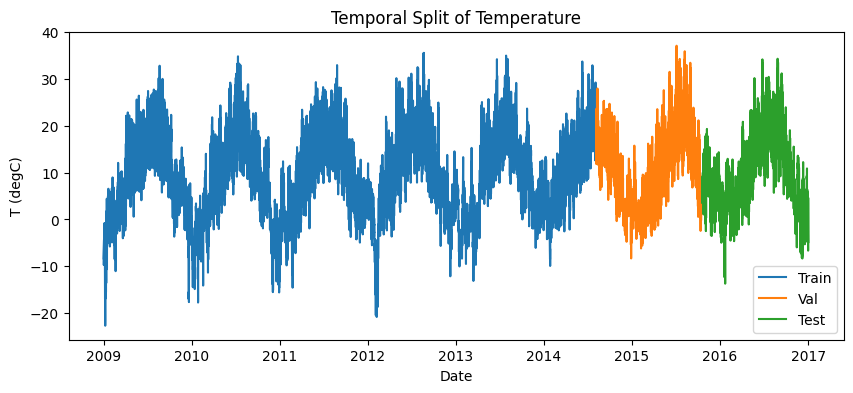

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(df_train.index, df_train[target_col], label="Train")
plt.plot(df_val.index,   df_val[target_col],   label="Val")
plt.plot(df_test.index,  df_test[target_col],  label="Test")
plt.title("Temporal Split of Temperature")
plt.xlabel("Date")
plt.ylabel("T (degC)")
plt.legend()
plt.show()

## 5.3 Feature Engineering

Additional time‑based features were engineered to help the models capture periodic patterns. From the datetime index, the hour of day and day of year were extracted and encoded using sine and cosine transformations to represent their cyclical nature. Wind direction was also encoded as circular features using sine and cosine. These engineered features enrich the input space with explicit representations of daily and annual seasonality.

In [39]:
def add_time_features(df_in):
    df = df_in.copy()
    # time parts
    hour = df.index.hour
    doy  = df.index.dayofyear

    # cyclical encoding
    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    df["doy_sin"]  = np.sin(2 * np.pi * doy / 365.25)
    df["doy_cos"]  = np.cos(2 * np.pi * doy / 365.25)

    # wind direction is circular
    wd = df["wd (deg)"].astype(float)
    df["wd_sin"] = np.sin(2 * np.pi * wd / 360.0)
    df["wd_cos"] = np.cos(2 * np.pi * wd / 360.0)

    return df

df_train_fe = add_time_features(df_train)
df_val_fe   = add_time_features(df_val)
df_test_fe  = add_time_features(df_test)

print(df_train_fe.shape, df_val_fe.shape, df_test_fe.shape)

(49026, 12) (10505, 12) (10507, 12)


## 5.4 Feature Scaling

All input features, including the engineered time features, were standardised using `StandardScaler`. The scaler was fitted on the training set only, and the same transformation was then applied to the validation and test sets. This ensures that all variables have zero mean and unit variance, which is particularly important for gradient‑based optimisation and neural network training. A final check confirmed that no NaN values were introduced during scaling.

In [40]:
from sklearn.preprocessing import StandardScaler

# Choose features to scale (all columns)
feat_cols = df_train_fe.columns.tolist()

scaler = StandardScaler()
scaler.fit(df_train_fe[feat_cols])

train_scaled = scaler.transform(df_train_fe[feat_cols])
val_scaled   = scaler.transform(df_val_fe[feat_cols])
test_scaled  = scaler.transform(df_test_fe[feat_cols])

# Back to DataFrame (keep index)
df_train_s = pd.DataFrame(train_scaled, index=df_train_fe.index, columns=feat_cols)
df_val_s   = pd.DataFrame(val_scaled,   index=df_val_fe.index,   columns=feat_cols)
df_test_s  = pd.DataFrame(test_scaled,  index=df_test_fe.index,  columns=feat_cols)

print("NaNs after scaling:", df_train_s.isna().sum().sum(), df_val_s.isna().sum().sum(), df_test_s.isna().sum().sum())

NaNs after scaling: 0 0 0


## 5.5 Windowing (L = 120, H = 24)

To cast the time series forecasting problem into a supervised learning setting, sliding windows were constructed over the scaled data. Each input sample consists of the previous L = 120 hours (5 days) of observations, and the corresponding target is the temperature over the next H = 24 hours. This windowing strategy allows the models to learn from recent history to predict the full 24‑hour temperature profile ahead.

In [41]:
from numpy.lib.stride_tricks import sliding_window_view

L = 120  # input window (hours)
H = 24   # forecast horizon (hours)

def make_windows(df_scaled, target_name, L, H):
    # Cast to float32 once here — avoids repeated float64→float32
    # conversion inside TensorFlow on every batch during training.
    data = df_scaled.values.astype(np.float32)
    target_idx = df_scaled.columns.get_loc(target_name)
    n_samples = len(data) - L - H

    # Build X windows fully vectorized using stride tricks — no Python loop.
    # sliding_window_view(data, L, axis=0) → (n-L+1, n_features, L)
    # transpose(0,2,1)                     → (n-L+1, L, n_features)
    # [:n_samples]                          → (n_samples, L, n_features)
    X = sliding_window_view(data, window_shape=L, axis=0).transpose(0, 2, 1)[:n_samples].copy()

    # Build y windows: target column only, H steps ahead of each X window.
    # sliding_window_view on target[L:] → (n-L-H+1, H), take [:n_samples]
    y = sliding_window_view(data[L:, target_idx], window_shape=H)[:n_samples].copy()

    return X, y

X_train, y_train = make_windows(df_train_s, target_col, L, H)
X_val,   y_val   = make_windows(df_val_s,   target_col, L, H)
X_test,  y_test  = make_windows(df_test_s,  target_col, L, H)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)
print("dtype:", X_train.dtype)

X_train: (48882, 120, 12) y_train: (48882, 24)
X_val:   (10361, 120, 12) y_val:   (10361, 24)
X_test:  (10363, 120, 12) y_test:  (10363, 24)
dtype: float32


### 5.5.1 Baseline: Persistence

As a simple baseline, a persistence model was implemented. For each window, the model predicts that the temperature for all 24 forecast hours will be equal to the last observed temperature in the input window. Although naive, this baseline provides a meaningful lower bound on performance and helps to contextualise the results of more complex models.

In [42]:
# persistence: predict next 24 hours as last observed temperature in the input window
target_idx = df_test_s.columns.get_loc(target_col)

last_T = X_test[:, -1, target_idx]  # last temp in each window
y_pred_persist = np.repeat(last_T[:, None], y_test.shape[1], axis=1)

print(y_pred_persist.shape)

(10363, 24)


### 5.5.2 Evaluation Metrics

The performance of the multi‑horizon forecasts was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), computed over all horizons and all samples. These metrics quantify the average magnitude of the prediction errors and penalise larger deviations more strongly in the case of RMSE. The persistence baseline achieves an MAE of approximately 0.36 (scaled units) and an RMSE of about 0.49, which serves as a reference for subsequent models.


In [43]:
def eval_multihorizon(y_true, y_pred):
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1)))
    return mae, rmse

mae_p, rmse_p = eval_multihorizon(y_test, y_pred_persist)
print("Persistence - MAE:", mae_p, "RMSE:", rmse_p)

Persistence - MAE: 0.36366111040115356 RMSE: 0.49212988258867824


### 5.5.3 MAE by Horizon

To analyse how forecast accuracy degrades with time, the MAE was computed separately for each forecast horizon from 1 to 24 hours ahead. The error profile shows that the MAE increases for intermediate horizons and then slightly decreases for the farthest horizons, reflecting the interaction between daily cycles and the persistence assumption. This horizon‑wise analysis provides a more detailed view of model behaviour than a single aggregated metric.

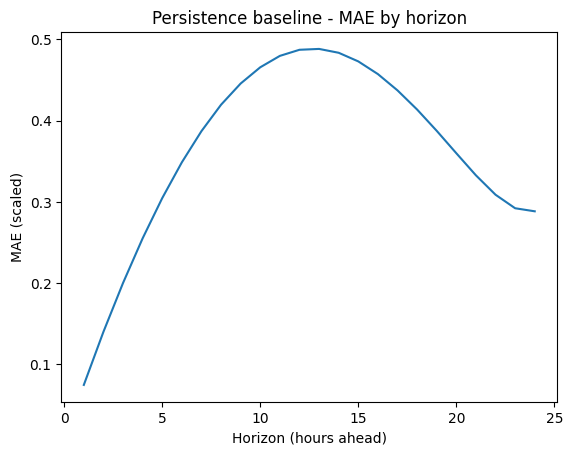

In [44]:
mae_by_h = np.mean(np.abs(y_test - y_pred_persist), axis=0)

plt.figure()
plt.plot(range(1, len(mae_by_h) + 1), mae_by_h)
plt.title("Persistence baseline - MAE by horizon")
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("MAE (scaled)")
plt.show()

# 6. Model GRU

This section describes the construction, configuration and optimisation of a GRU-based neural network for multi‑horizon temperature forecasting. The workflow includes GPU setup, reproducibility settings, model architecture definition, training procedures, and hyperparameter optimisation using Optuna.


In [45]:
print("TF version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs found:", gpus)

if gpus:
    # Avoid TF grabbing all GPU memory at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU is available and memory growth is enabled.")
else:
    print("No GPU found. Training will run on CPU.")

TF version: 2.20.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available and memory growth is enabled.


## 6.1 Setup: Reproducibility

To ensure consistent and repeatable results across runs, random seeds were fixed for both TensorFlow and NumPy. The input window length (L), forecast horizon (H) and number of features were also extracted from the training data to parameterise the model architecture.

In [46]:
tf.random.set_seed(42)
np.random.seed(42)

H = y_train.shape[1]
L = X_train.shape[1]
n_features = X_train.shape[2]

## 6.2 Model Architecture and Hyperparameters

A flexible GRU model was implemented, supporting one to three recurrent layers with configurable units, dropout, L2 regularisation and optional Gaussian noise. The architecture also allows an optional dense head before the output layer, enabling additional non‑linear transformations. The output layer produces a vector of length H, corresponding to the 24‑hour forecast horizon. Multiple hyperparameters—including learning rate, optimiser type, activation functions and weight decay—can be adjusted to explore different model configurations.

In [47]:
def build_gru_model(
    L, n_features, H,
    units1=64,
    units2=32,
    n_layers=1,
    dropout=0.2,
    l2=0.0,
    dense_units=0,
    dense_activation="relu",
    learning_rate=1e-3,
    clipnorm=1.0,
    optimizer_name="adam",
    # --- new (optional) params, defaults keep old behavior ---
    units3=32,
    weight_decay=1e-5,          # used only if adamw
    loss_name="mse",            # mse/mae/huber1/huber2
    gaussian_noise_std=0.0,     # 0 disables
):
    reg = keras.regularizers.l2(l2) if l2 and l2 > 0 else None

    inputs = keras.Input(shape=(L, n_features))
    x = inputs

    # Optional input noise
    if gaussian_noise_std and gaussian_noise_std > 0:
        x = layers.GaussianNoise(gaussian_noise_std)(x)

    # GRU stack (supports 1/2/3 layers).
    # recurrent_dropout=0.0 is required to use the fast cuDNN GRU kernel on GPU.
    x = layers.GRU(
        units1,
        return_sequences=(n_layers >= 2),
        dropout=dropout,
        recurrent_dropout=0.0,
        kernel_regularizer=reg
    )(x)

    if n_layers >= 2:
        x = layers.GRU(
            units2,
            return_sequences=(n_layers == 3),
            dropout=dropout,
            recurrent_dropout=0.0,
            kernel_regularizer=reg
        )(x)

    if n_layers == 3:
        x = layers.GRU(
            units3,
            return_sequences=False,
            dropout=dropout,
            recurrent_dropout=0.0,
            kernel_regularizer=reg
        )(x)

    # Optional dense head with extra activations
    if dense_units and dense_units > 0:
        if dense_activation == "leaky_relu":
            x = layers.Dense(dense_units, kernel_regularizer=reg)(x)
            x = layers.LeakyReLU(negative_slope=0.1)(x)
        else:
            x = layers.Dense(dense_units, activation=dense_activation, kernel_regularizer=reg)(x)
        x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(H)(x)  # linear output
    model = keras.Model(inputs, outputs)

    # Optimizer
    if optimizer_name.lower() == "adamw":
        opt = keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            clipnorm=clipnorm
        )
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm)

    # Loss
    if loss_name == "mae":
        loss = "mae"
    elif loss_name == "huber1":
        loss = keras.losses.Huber(delta=1.0)
    elif loss_name == "huber2":
        loss = keras.losses.Huber(delta=2.0)
    else:
        loss = "mse"

    model.compile(optimizer=opt, loss=loss, metrics=["mae"])
    return model

## 6.3 Training Wrapper and Callbacks

A training wrapper function was created to streamline model training under different hyperparameter configurations. The training process uses early stopping to prevent overfitting and a learning‑rate scheduler to improve convergence. For each configuration, the function returns the trained model, the training history, and the best validation metrics achieved during training.

In [48]:
def train_one_config(cfg, X_train, y_train, X_val, y_val, max_epochs=60, fit_verbose=0):
    model = build_gru_model(
        L=L, n_features=n_features, H=H,
        units1=cfg["units1"],
        units2=cfg["units2"],
        n_layers=cfg["n_layers"],
        dropout=cfg["dropout"],
        l2=cfg["l2"],
        dense_units=cfg["dense_units"],
        dense_activation=cfg["dense_activation"],
        learning_rate=cfg["lr"],
        clipnorm=cfg["clipnorm"],
        optimizer_name=cfg["optimizer"],
        # new params
        units3=cfg.get("units3", 32),
        weight_decay=cfg.get("weight_decay", 0.0),
        loss_name=cfg.get("loss_name", "mse"),
        gaussian_noise_std=cfg.get("gaussian_noise_std", 0.0),
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=cfg["batch_size"],
        verbose=fit_verbose,
        callbacks=callbacks
    )

    best_val_loss = float(np.min(history.history["val_loss"]))
    best_val_mae  = float(np.min(history.history["val_mae"]))
    return model, history, best_val_loss, best_val_mae

## 6.4 Random Hyperparameter Search

Hyperparameter optimisation was performed using Optuna with a TPE sampler, which models the loss landscape and focuses the search on promising regions. A custom pruning callback was implemented to stop underperforming trials early, reducing computational cost. Each trial samples a combination of architectural and training hyperparameters, trains a GRU model, and reports validation loss to Optuna. The study tracks the best model configuration and provides visual feedback on optimisation progress, including validation loss evolution and trial durations.

In [49]:
# Custom pruning callback — avoids dependency on optuna.integration.*
# After each epoch it reports val_loss to Optuna; if Optuna's Hyperband pruner
# decides this trial is unlikely to beat the current best, it raises TrialPruned
# and Keras stops training immediately, saving compute.
class OptunaPruningCallback(keras.callbacks.Callback):
    def __init__(self, trial):
        super().__init__()
        self.trial = trial

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get("val_loss")
        if val_loss is None:
            return
        self.trial.report(val_loss, epoch)
        if self.trial.should_prune():
            raise optuna.exceptions.TrialPruned()


# Mutable dict to keep the best Keras model across trials.
# Optuna tracks hyperparameters and val_loss, but not model objects.
best_holder = {"val_loss": np.inf, "model": None, "cfg": None, "history": None}


def objective(trial):
    # ── Sample hyperparameters via TPE (Bayesian) ────────────────────────────
    n_layers    = trial.suggest_int("n_layers", 1, 3)
    units1      = trial.suggest_categorical("units1",      [64, 96, 128, 192])
    units2      = trial.suggest_categorical("units2",      [32, 64, 96, 128])
    units3      = trial.suggest_categorical("units3",      [32, 64, 96])
    dropout     = trial.suggest_categorical("dropout",     [0.0, 0.1, 0.2, 0.3, 0.4])
    l2          = trial.suggest_categorical("l2",          [0.0, 1e-6, 1e-5, 1e-4])
    dense_units = trial.suggest_categorical("dense_units", [0, 64, 128, 256])
    dense_act   = trial.suggest_categorical("dense_activation", ["relu", "gelu", "elu", "leaky_relu"])
    lr          = trial.suggest_categorical("lr",          [2e-3, 1e-3, 5e-4, 3e-4, 2e-4, 1e-4])
    batch_size  = trial.suggest_categorical("batch_size",  [128, 256, 512])
    clipnorm    = trial.suggest_categorical("clipnorm",    [0.5, 1.0, 2.0, 5.0])
    opt_name    = trial.suggest_categorical("optimizer",   ["adam", "adamw"])
    weight_decay= trial.suggest_categorical("weight_decay",[0.0, 1e-6, 1e-5, 1e-4])
    loss_name   = trial.suggest_categorical("loss_name",   ["mse", "mae", "huber1", "huber2"])
    noise_std   = trial.suggest_categorical("gaussian_noise_std", [0.0, 0.01, 0.05])

    # ── Apply same constraints as the random search ──────────────────────────
    if units2 > units1:   units2 = units1
    if units3 > units2:   units3 = units2
    if opt_name == "adam": weight_decay = 0.0
    if n_layers == 1 and dense_units > 0 and random.random() < 0.7:
        dense_units = 0

    cfg = dict(
        n_layers=n_layers, units1=units1, units2=units2, units3=units3,
        dropout=dropout, l2=l2, dense_units=dense_units, dense_activation=dense_act,
        lr=lr, batch_size=batch_size, clipnorm=clipnorm, optimizer=opt_name,
        weight_decay=weight_decay, loss_name=loss_name, gaussian_noise_std=noise_std,
    )

    model = build_gru_model(
        L=L, n_features=n_features, H=H,
        units1=units1, units2=units2, units3=units3,
        n_layers=n_layers, dropout=dropout, l2=l2,
        dense_units=dense_units, dense_activation=dense_act,
        learning_rate=lr, clipnorm=clipnorm,
        optimizer_name=opt_name, weight_decay=weight_decay,
        loss_name=loss_name, gaussian_noise_std=noise_std,
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
        OptunaPruningCallback(trial),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=batch_size,
        verbose=0,
        callbacks=callbacks,
    )

    val_loss = float(np.min(history.history["val_loss"]))
    val_mae  = float(np.min(history.history["val_mae"]))

    trial.set_user_attr("val_mae", val_mae)

    if val_loss < best_holder["val_loss"]:
        best_holder.update({"val_loss": val_loss, "model": model, "history": history, "cfg": cfg})

    return val_loss


## 6.5 Run Random Search

A random hyperparameter search was executed using Optuna, combining a TPE sampler with a Hyperband pruner. The TPE sampler models the loss landscape after an initial warm‑up phase and focuses sampling on promising regions, while the Hyperband pruner terminates underperforming trials early based on validation loss. A custom callback was implemented to provide live visual feedback after each trial, including validation loss progression and trial durations. This setup enables efficient exploration of the hyperparameter space while reducing computational cost.

[60/60] Trial #59 → PRUNED
  Complete: 27 | Pruned: 33 | Best so far: 0.0353


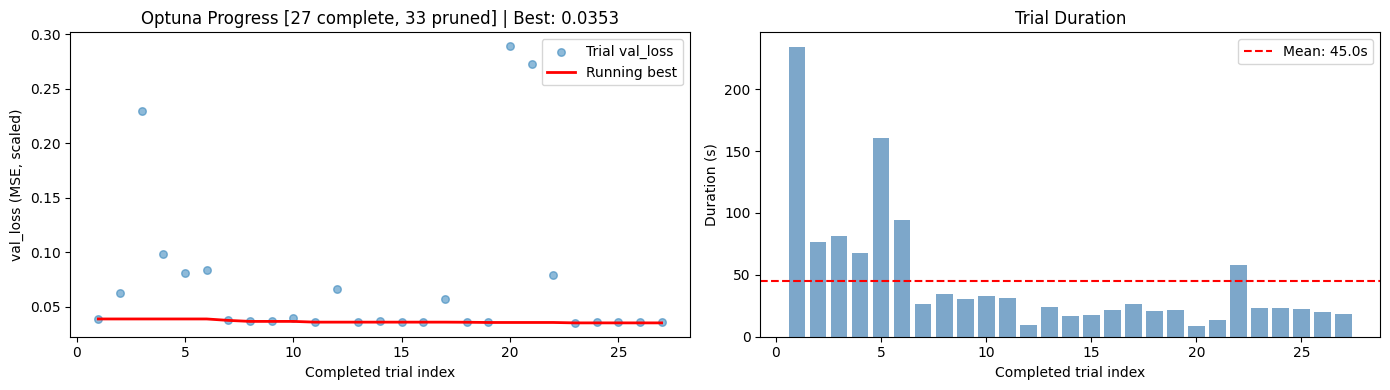


Optimization complete!
Best trial #41 — val_loss: 0.0353
Best params: {'n_layers': 1, 'units1': 96, 'units2': 96, 'units3': 32, 'dropout': 0.0, 'l2': 1e-06, 'dense_units': 64, 'dense_activation': 'relu', 'lr': 0.001, 'batch_size': 512, 'clipnorm': 5.0, 'optimizer': 'adamw', 'weight_decay': 0.0001, 'loss_name': 'huber1', 'gaussian_noise_std': 0.0}


In [50]:
from IPython.display import clear_output

def progress_callback(study, trial):
    """Live chart redrawn after every trial (complete or pruned)."""
    clear_output(wait=True)
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    n_done    = len(study.trials)

    state_str = ("PRUNED" if trial.state == optuna.trial.TrialState.PRUNED
                 else f"val_loss={trial.value:.4f}")
    print(f"[{n_done}/60] Trial #{trial.number} → {state_str}")
    if completed:
        print(f"  Complete: {len(completed)} | Pruned: {len(pruned)} | Best so far: {study.best_value:.4f}")

    if len(completed) < 2:
        return

    losses       = [t.value for t in completed]
    running_best = pd.Series(losses).cummin()
    durations    = [t.duration.total_seconds() for t in completed if t.duration]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.scatter(range(1, len(losses) + 1), losses, alpha=0.5, s=30, label="Trial val_loss")
    ax.plot(range(1, len(losses) + 1), running_best, color="red", linewidth=2, label="Running best")
    ax.set_title(f"Optuna Progress [{len(completed)} complete, {len(pruned)} pruned]"
                 f" | Best: {study.best_value:.4f}")
    ax.set_xlabel("Completed trial index")
    ax.set_ylabel("val_loss (MSE, scaled)")
    ax.legend()

    ax = axes[1]
    ax.bar(range(1, len(durations) + 1), durations, color="steelblue", alpha=0.7)
    if durations:
        ax.axhline(np.mean(durations), color="red", linestyle="--",
                   label=f"Mean: {np.mean(durations):.1f}s")
    ax.set_title("Trial Duration")
    ax.set_xlabel("Completed trial index")
    ax.set_ylabel("Duration (s)")
    ax.legend()

    plt.tight_layout()
    plt.show()


# TPE sampler: Bayesian optimisation via Tree-structured Parzen Estimators.
# After an initial random phase (~10 trials) it models the loss landscape
# and focuses sampling on promising regions — unlike pure random search.
#
# HyperbandPruner: kills unpromising trials early based on epoch-level val_loss.
# min_resource=3  → every trial runs at least 3 epochs before pruning kicks in.
# max_resource=40 → matches our max_epochs.
# reduction_factor=3 → each bracket keeps the top 1/3 of trials.
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.HyperbandPruner(min_resource=3, max_resource=40, reduction_factor=3),
)

study.optimize(objective, n_trials=60, callbacks=[progress_callback])

print("\nOptimization complete!")
print(f"Best trial #{study.best_trial.number} — val_loss: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


## 6.6 Results of Random Search (Completed Trials Summary)

After the random search finished, all completed Optuna trials were collected and organised into a results table.  
Each trial’s validation loss, validation MAE, training time and full set of sampled hyperparameters were stored in a unified DataFrame.  
Pruned trials were excluded from the table, ensuring that only fully evaluated configurations were compared.

The trials were then sorted by validation loss, allowing the identification of the best-performing hyperparameter sets.  
The best configuration was extracted and stored for downstream evaluation, together with its trained model and training history.  
This structured summary enables transparent comparison between trials and supports reproducibility of the selected GRU configuration.


In [51]:
# Build results_df from completed Optuna trials in the same column format
# as the random search version so all downstream evaluation cells work unchanged.
rows = []
for t in study.trials:
    if t.state != optuna.trial.TrialState.COMPLETE:
        continue
    row = {
        "name":           f"trial_{t.number:02d}",
        "best_val_loss":  t.value,
        "best_val_mae":   t.user_attrs.get("val_mae", np.nan),
        "train_time_sec": round(t.duration.total_seconds(), 1) if t.duration else np.nan,
        **t.params,
    }
    rows.append(row)

n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
results_df = pd.DataFrame(rows).sort_values("best_val_loss").reset_index(drop=True)

print(f"Completed trials: {len(rows)} | Pruned: {n_pruned}")
display(results_df.head(10))

# Compatibility aliases — downstream cells reference these names.
# Inject "name" into cfg so title labels in evaluation cells work unchanged.
best_cfg_named = {**best_holder["cfg"], "name": f"trial_{study.best_trial.number:02d}"}
best = {
    "val_loss": best_holder["val_loss"],
    "model":    best_holder["model"],
    "history":  best_holder["history"],
    "cfg":      best_cfg_named,
}
best_gru = best_holder["model"]

Completed trials: 27 | Pruned: 33


,name,best_val_loss,best_val_mae,train_time_sec,n_layers,units1,units2,units3,dropout,l2,dense_units,dense_activation,lr,batch_size,clipnorm,optimizer,weight_decay,loss_name,gaussian_noise_std
0,trial_41,0.035266,0.198800,22.8,1,96,96,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0
1,trial_32,0.035645,0.198917,22.0,1,96,64,32,0.0,0.000001,64,relu,0.0010,512,5.0,adam,0.000100,huber1,0.0
2,trial_26,0.035849,0.199704,20.6,1,128,128,32,0.0,0.000001,64,relu,0.0010,512,5.0,adam,0.000100,huber1,0.0
3,trial_14,0.035953,0.199842,31.1,1,128,96,32,0.0,0.000001,64,relu,0.0005,512,5.0,adamw,0.000100,huber1,0.0
4,trial_22,0.036177,0.201122,17.9,1,128,96,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0
5,trial_23,0.036209,0.200784,21.3,1,96,96,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0
6,trial_53,0.036248,0.200904,18.3,1,96,96,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0
7,trial_45,0.036354,0.201542,22.5,1,128,128,64,0.0,0.000001,64,relu,0.0010,512,2.0,adamw,0.000001,huber1,0.0
8,trial_43,0.036356,0.200363,23.1,1,96,32,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0
9,trial_17,0.036430,0.200855,23.8,1,96,96,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0


## 6.7 Training Curves (Best GRU)

The training and validation curves of the best GRU model were analysed to assess convergence behaviour. The loss (MSE) and MAE curves show smooth and stable training dynamics, with validation metrics closely following the training curves.  This indicates that the model generalises well and does not exhibit signs of overfitting. The selected configuration corresponds to the trial with the lowest validation loss during the Optuna search.

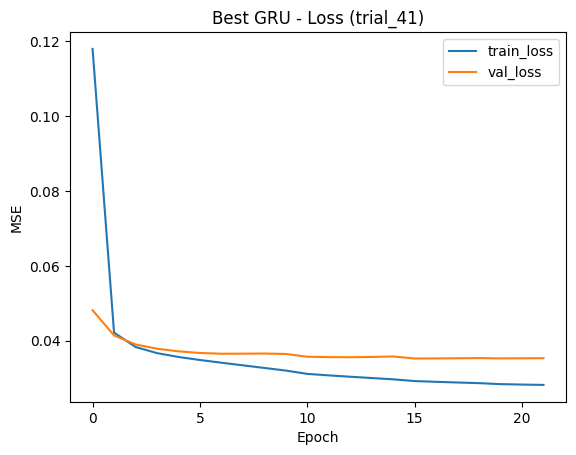

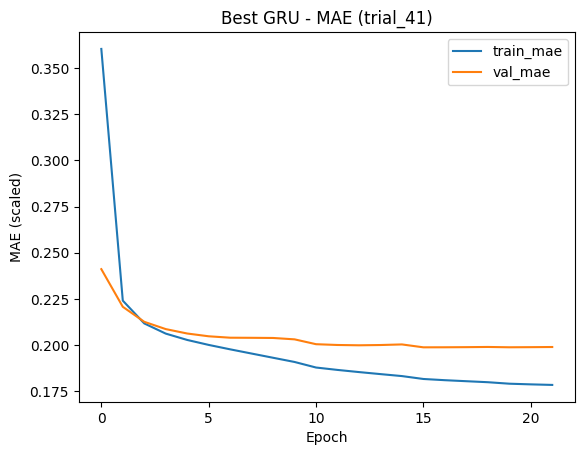

In [52]:
hist = best["history"].history

plt.figure()
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title(f"Best GRU - Loss ({best['cfg']['name']})")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist["mae"], label="train_mae")
plt.plot(hist["val_mae"], label="val_mae")
plt.title(f"Best GRU - MAE ({best['cfg']['name']})")
plt.xlabel("Epoch")
plt.ylabel("MAE (scaled)")
plt.legend()
plt.show()

## 6.8 Evaluation on Test Set (Scaled)

The best GRU model was evaluated on the test set using scaled values. The model achieved strong performance, with low MAE and RMSE and a high R² score, indicating that it captures most of the variance in the target series. MAPE was not computed in scaled units, as it is not meaningful before inverse transformation.

In [53]:
best_gru = best["model"]
y_pred_gru_scaled = best_gru.predict(X_test, verbose=0)

yt = y_test.reshape(-1)
yp = y_pred_gru_scaled.reshape(-1)

mae = mean_absolute_error(yt, yp)
rmse = np.sqrt(mean_squared_error(yt, yp))
r2 = r2_score(yt, yp)

# MAPE on scaled units is not meaningful; we'll compute MAPE in °C after inverse-scaling.
print("TEST (scaled) - MAE:", mae, "RMSE:", rmse, "R2:", r2)

TEST (scaled) - MAE: 0.19629062712192535 RMSE: 0.2594626531370501 R2: 0.9175846576690674


## 6.9 Inverse Scaling and Metrics in °C

Predictions and ground‑truth values were transformed back to degrees Celsius using the inverse of the standardisation applied during preprocessing. This allows evaluation in physically interpretable units. The model maintains strong performance after inverse scaling, confirming that the learned patterns translate well to the original temperature scale.

In [54]:
def inverse_scale_target(y_scaled, scaler, feature_names, target_col):
    t_idx = feature_names.index(target_col)
    mean = scaler.mean_[t_idx]
    std  = scaler.scale_[t_idx]
    return y_scaled * std + mean

y_test_c = inverse_scale_target(y_test, scaler, feat_cols, target_col)
y_pred_c = inverse_scale_target(y_pred_gru_scaled, scaler, feat_cols, target_col)

### 6.9.1 Metrics in °C (Global + MAPE)

After converting predictions to °C, global metrics were computed: MAE, RMSE, MAPE and R². The GRU model achieves low absolute error and a high coefficient of determination, demonstrating accurate multi‑horizon temperature forecasting. MAPE remains below 0.17, indicating robust relative accuracy across the full forecast horizon.

In [55]:
eps = 1e-6
yt = y_test_c.reshape(-1)
yp = y_pred_c.reshape(-1)

mae_c = mean_absolute_error(yt, yp)
rmse_c = np.sqrt(mean_squared_error(yt, yp))
r2_c = r2_score(yt, yp)

print("TEST (°C) - MAE:", mae_c, "RMSE:", rmse_c, "R2:", r2_c)

TEST (°C) - MAE: 1.6968425834562746 RMSE: 2.242935730747733 R2: 0.9175846880740695


## 6.10 MAE by Horizon

To analyse how forecast accuracy evolves with increasing horizon, the MAE was computed separately for each of the 24 forecast hours. The error increases gradually with horizon, as expected in multi‑step forecasting, but remains within acceptable limits across all hours. This horizon‑wise evaluation provides deeper insight into the temporal behaviour of the model’s predictive performance.

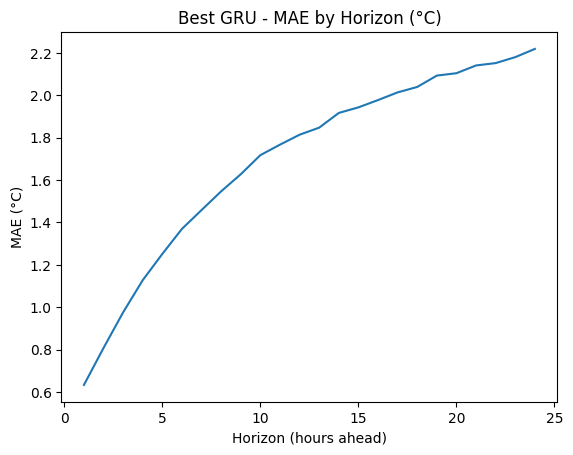

In [56]:
H = y_test.shape[1]
mae_by_h = np.mean(np.abs(y_test_c - y_pred_c), axis=0)

plt.figure()
plt.plot(range(1, H+1), mae_by_h)
plt.title("Best GRU - MAE by Horizon (°C)")
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("MAE (°C)")
plt.show()

In [57]:
results_df.to_csv("gru_random_search_results.csv", index=False)

# 7. Overview of Hyperparameter Configurations

This section presents an overview of the configurations explored during the hyperparameter search for the GRU-based forecasting model. Each row in the table corresponds to a specific experimental configuration, including architectural choices (such as the number of layers and hidden units), regularization parameters (dropout and weight decay), optimization settings (learning rate, optimizer type, and batch size), and loss functions.

For each configuration, the table reports several performance indicators obtained during validation, including the best validation loss and the corresponding validation MAE (Mean Absolute Error). These metrics allow us to compare different configurations and identify the most promising models.

To facilitate interpretation, the results are sorted according to the validation loss. The top configurations represent the models that achieved the lowest validation error, while the bottom configurations correspond to the least effective parameter combinations. In total, 27 different configurations were evaluated during the random search procedure.

The best-performing configuration achieved a validation loss of approximately 0.0353 and a validation MAE of approximately 0.1966, indicating that the GRU architecture is capable of capturing relevant temporal dependencies present in the meteorological time series.

In [58]:
display(results_df.head(10))     # top 10
display(results_df.tail(10))     # worst 10
print("Configs tested:", len(results_df))
print("Best val_loss:", results_df["best_val_loss"].min())
print("Best val_mae:", results_df["best_val_mae"].min())

,name,best_val_loss,best_val_mae,train_time_sec,n_layers,units1,units2,units3,dropout,l2,dense_units,dense_activation,lr,batch_size,clipnorm,optimizer,weight_decay,loss_name,gaussian_noise_std
0,trial_41,0.035266,0.198800,22.8,1,96,96,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0
1,trial_32,0.035645,0.198917,22.0,1,96,64,32,0.0,0.000001,64,relu,0.0010,512,5.0,adam,0.000100,huber1,0.0
2,trial_26,0.035849,0.199704,20.6,1,128,128,32,0.0,0.000001,64,relu,0.0010,512,5.0,adam,0.000100,huber1,0.0
3,trial_14,0.035953,0.199842,31.1,1,128,96,32,0.0,0.000001,64,relu,0.0005,512,5.0,adamw,0.000100,huber1,0.0
4,trial_22,0.036177,0.201122,17.9,1,128,96,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0
5,trial_23,0.036209,0.200784,21.3,1,96,96,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0
6,trial_53,0.036248,0.200904,18.3,1,96,96,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0
7,trial_45,0.036354,0.201542,22.5,1,128,128,64,0.0,0.000001,64,relu,0.0010,512,2.0,adamw,0.000001,huber1,0.0
8,trial_43,0.036356,0.200363,23.1,1,96,32,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0
9,trial_17,0.036430,0.200855,23.8,1,96,96,32,0.0,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.0


,name,best_val_loss,best_val_mae,train_time_sec,n_layers,units1,units2,units3,dropout,l2,dense_units,dense_activation,lr,batch_size,clipnorm,optimizer,weight_decay,loss_name,gaussian_noise_std
17,trial_25,0.056908,0.266182,26.4,1,96,96,32,0.3,0.000001,64,relu,0.0010,512,5.0,adamw,0.000100,huber1,0.00
18,trial_04,0.062488,0.270559,76.2,2,64,64,64,0.3,0.000100,0,elu,0.0020,256,5.0,adamw,0.000000,huber2,0.01
19,trial_16,0.066490,0.284833,9.2,1,128,96,32,0.3,0.000001,64,gelu,0.0003,512,1.0,adamw,0.000100,huber1,0.00
20,trial_40,0.079174,0.209940,57.9,1,64,128,96,0.1,0.000001,128,elu,0.0020,128,5.0,adam,0.000000,mse,0.00
21,trial_08,0.080928,0.217294,160.5,1,64,64,64,0.1,0.000000,256,elu,0.0005,128,0.5,adamw,0.000001,mse,0.05
22,trial_09,0.083687,0.221468,94.5,2,192,128,96,0.1,0.000000,128,elu,0.0001,256,2.0,adamw,0.000001,mse,0.05
23,trial_07,0.098825,0.312366,68.0,3,192,32,64,0.4,0.000100,128,elu,0.0001,128,2.0,adam,0.000010,huber1,0.00
24,trial_05,0.229378,0.229378,81.1,2,64,32,32,0.2,0.000000,0,leaky_relu,0.0010,128,0.5,adam,0.000010,mae,0.00
25,trial_36,0.272123,0.272096,13.3,1,128,32,96,0.3,0.000001,0,leaky_relu,0.0010,256,5.0,adam,0.000000,mae,0.00
26,trial_34,0.288884,0.288860,8.4,1,192,64,32,0.4,0.000001,64,relu,0.0002,512,5.0,adam,0.000100,mae,0.00


Configs tested: 27
Best val_loss: 0.03526591882109642
Best val_mae: 0.19655433297157288


## 7.1 Distribution of Validation Performance

To better understand the variability of model performance across the explored configurations, histograms were generated for the best validation loss and best validation MAE obtained during training.

The histogram of validation loss shows that the majority of configurations achieve relatively low error values, concentrated around a narrow interval near the lower end of the distribution. This suggests that many hyperparameter combinations produce reasonably stable models, although a small number of configurations result in significantly worse performance.

A similar pattern can be observed in the distribution of the validation MAE. Most configurations cluster around similar error levels, while a few outliers correspond to models that failed to generalize effectively to the validation data.

Overall, these distributions indicate that the hyperparameter search space contains several viable configurations, but also highlights the importance of systematic experimentation to identify the most effective combinations of architectural and optimization parameters.

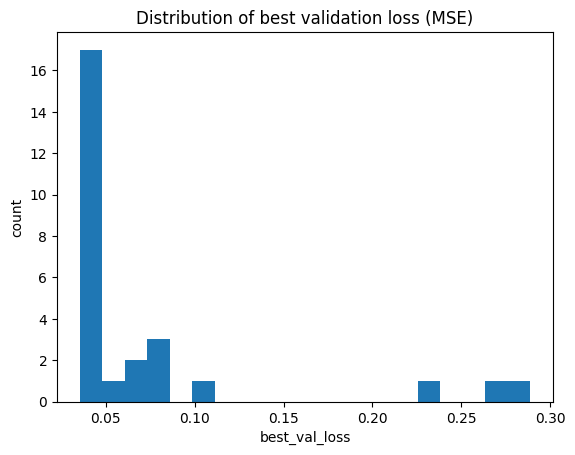

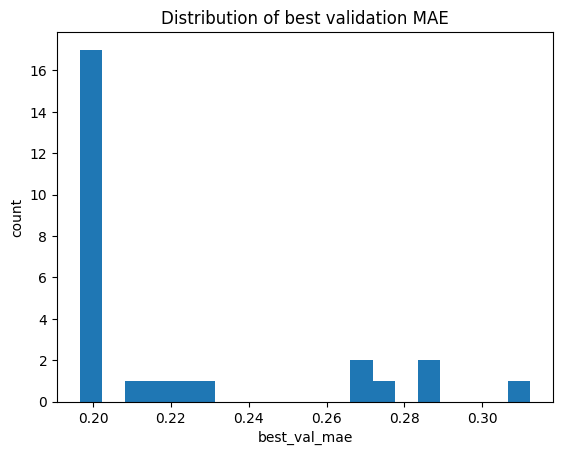

In [59]:
plt.figure()
plt.hist(results_df["best_val_loss"], bins=20)
plt.title("Distribution of best validation loss (MSE)")
plt.xlabel("best_val_loss")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(results_df["best_val_mae"], bins=20)
plt.title("Distribution of best validation MAE")
plt.xlabel("best_val_mae")
plt.ylabel("count")
plt.show()

## 7.2 Hyperparameter Search Progress and Learning Rate Analysis

The random search progress plot illustrates how the validation loss evolves as different configurations are evaluated. Each point corresponds to a tested configuration, while the red line represents the running best validation loss observed so far. The vertical dashed line indicates the configuration that achieved the lowest validation error during the search.

This visualization helps assess the efficiency of the random search procedure. The results suggest that a strong-performing configuration was discovered relatively early in the search process, after which subsequent configurations produced only minor improvements or comparable performance.

Additionally, a boxplot analysis of validation loss across different learning rates provides insight into the sensitivity of the model to this hyperparameter. The results indicate that certain learning rates consistently lead to lower validation errors, while others produce more unstable performance.

This analysis highlights the importance of carefully selecting the learning rate, as it strongly influences both convergence behaviour and the final predictive performance of the GRU model.

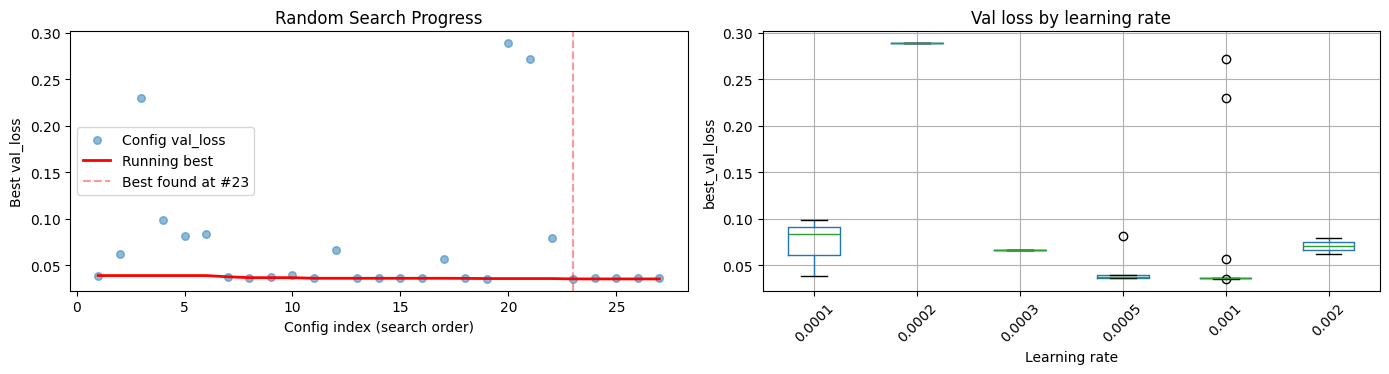

In [60]:
# Search progress chart
# results_df is sorted by val_loss; we recover search order via the config names (gru_rs_01...gru_rs_60)
results_order = results_df.sort_values("name").reset_index(drop=True)
x = range(1, len(results_order) + 1)
running_best = results_order["best_val_loss"].cummin()
best_idx = int(results_order["best_val_loss"].idxmin()) + 1  # 1-indexed position

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: val_loss per config + running best
ax = axes[0]
ax.scatter(x, results_order["best_val_loss"], alpha=0.5, s=30, label="Config val_loss")
ax.plot(x, running_best, color="red", linewidth=2, label="Running best")
ax.axvline(best_idx, color="red", linestyle="--", alpha=0.4, label=f"Best found at #{best_idx}")
ax.set_title("Random Search Progress")
ax.set_xlabel("Config index (search order)")
ax.set_ylabel("Best val_loss")
ax.legend()

# Right: val_loss by learning rate
ax = axes[1]
results_df.boxplot(column="best_val_loss", by="lr", ax=ax)
ax.set_title("Val loss by learning rate")
plt.suptitle("")
ax.set_xlabel("Learning rate")
ax.set_ylabel("best_val_loss")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7.3 Performance vs Training Time

The scatter plot illustrates the relationship between training time and validation performance for the different hyperparameter configurations evaluated during the random search.

Each point represents a single configuration, where the horizontal axis corresponds to the total training time (in seconds) and the vertical axis represents the best validation loss achieved by that model. Since lower validation loss indicates better predictive performance, points located closer to the bottom of the plot correspond to more accurate models.

The distribution of points suggests that longer training times do not necessarily lead to better performance. Several configurations with relatively short training times achieve validation losses comparable to, or even better than, models that require substantially longer training. This observation highlights the importance of selecting efficient model configurations that balance predictive performance and computational cost.

From a practical perspective, this type of visualization provides an intuitive Pareto-style interpretation, helping identify configurations that offer strong predictive performance while maintaining reasonable computational efficiency.

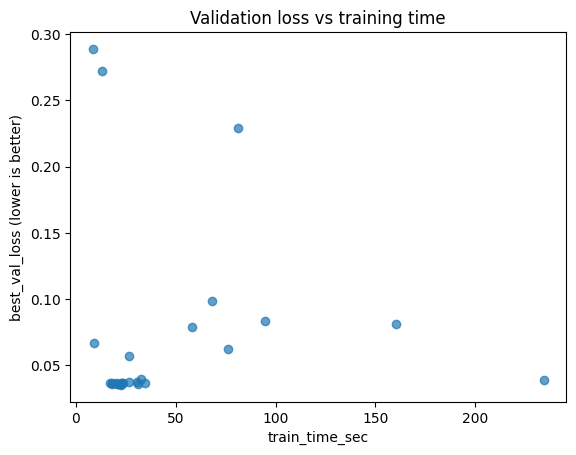

In [61]:
plt.figure()
plt.scatter(results_df["train_time_sec"], results_df["best_val_loss"], alpha=0.7)
plt.title("Validation loss vs training time")
plt.xlabel("train_time_sec")
plt.ylabel("best_val_loss (lower is better)")
plt.show()

## 7.4 Important Hyperparameters

To better understand how different architectural choices influence model performance, additional analyses were conducted focusing on key hyperparameters of the GRU architecture. In particular, we examine how validation performance varies with respect to the number of GRU layers, dropout rate, and optimizer choice.

These analyses provide insight into which hyperparameters have the strongest impact on forecasting performance and help guide the selection of more effective model configurations. By studying the distribution of validation loss across different hyperparameter values, we can identify patterns that reveal which architectural or training choices tend to produce more stable and accurate models.

### 7.4.1 Effect of the Number of GRU Layers

The boxplot above illustrates the distribution of validation loss across models with different numbers of GRU layers.

Models with a single GRU layer tend to achieve the lowest validation losses and also exhibit the smallest variability across configurations. This suggests that a relatively simple architecture is sufficient to capture the temporal dependencies present in the meteorological time series.

In contrast, configurations with two GRU layers show a wider distribution of validation loss values, indicating greater sensitivity to hyperparameter settings and potentially increased training instability. Models with three layers appear less frequently in the search space and do not show clear improvements over simpler architectures.

Overall, the results indicate that shallower architectures often perform competitively, highlighting that increasing model depth does not necessarily translate into better forecasting performance for this task.

<Figure size 640x480 with 0 Axes>

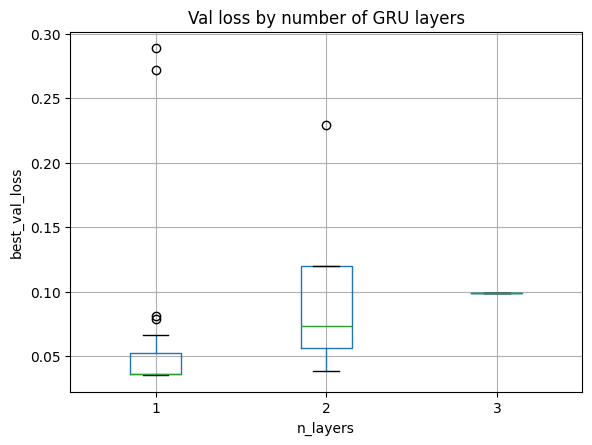

In [62]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="n_layers")
plt.title("Val loss by number of GRU layers")
plt.suptitle("")
plt.xlabel("n_layers")
plt.ylabel("best_val_loss")
plt.show()

### 7.4.2 Effect of Dropout Regularization

The boxplot shows how validation performance varies across different dropout rates, which are used as a regularization mechanism to reduce overfitting during training.

Configurations with little or no dropout tend to achieve the lowest validation losses, suggesting that the models are able to generalize effectively without requiring strong regularization. As the dropout rate increases, the validation loss generally becomes larger and more variable, indicating that excessive regularization may hinder the model's ability to learn meaningful temporal patterns.

Higher dropout values may remove too much information from the hidden representations during training, reducing the model's capacity to capture complex dependencies in the data.

These results suggest that moderate or minimal dropout values are more suitable for this forecasting task, balancing model capacity and generalization performance.

<Figure size 640x480 with 0 Axes>

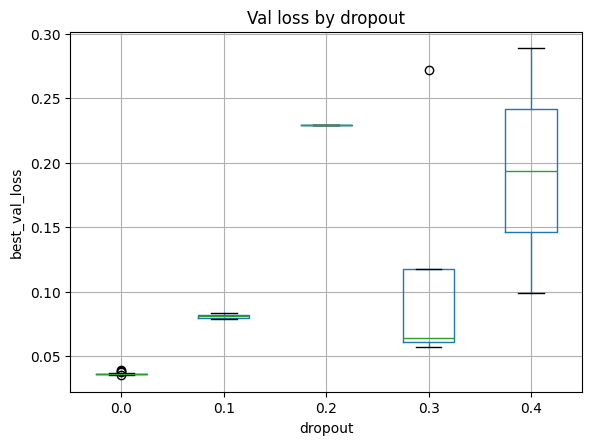

In [63]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="dropout")
plt.title("Val loss by dropout")
plt.suptitle("")
plt.xlabel("dropout")
plt.ylabel("best_val_loss")
plt.show()

### 7.4.3 Effect of the Optimizer

The final analysis compares model performance across different optimization algorithms used during training.

The boxplot indicates that configurations using AdamW generally achieve lower validation losses and exhibit more stable performance compared to those using the standard Adam optimizer. AdamW introduces decoupled weight decay, which improves regularization and often leads to better generalization in deep learning models.

In contrast, models trained with Adam show greater variability in validation performance and include several configurations with substantially higher validation loss values.

These observations suggest that AdamW provides a more stable and effective optimization strategy for training the GRU-based forecasting model in this task.

<Figure size 640x480 with 0 Axes>

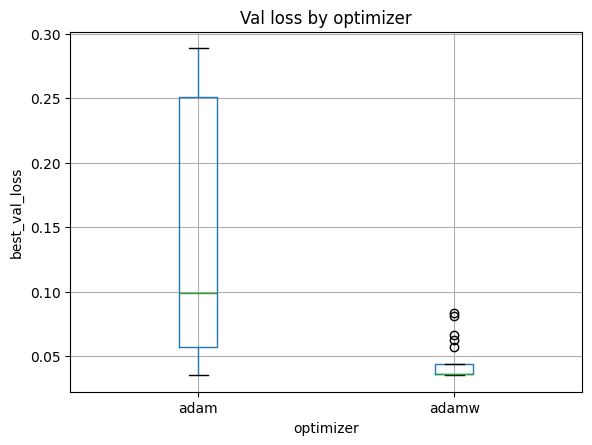

In [64]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="optimizer")
plt.title("Val loss by optimizer")
plt.suptitle("")
plt.xlabel("optimizer")
plt.ylabel("best_val_loss")
plt.show()

# 8. Model Evaluation and Forecast Analysis

This section presents a detailed evaluation of the forecasting performance of the proposed GRU model on the test dataset. Beyond aggregate performance metrics, the analysis focuses on understanding how the model behaves across different forecasting horizons and how accurately it captures the temporal dynamics of the temperature series.

Several complementary analyses are conducted in order to assess the robustness and reliability of the model. These include a comparison with a simple baseline model, an examination of prediction error distributions, and visual inspections of predicted and true temperature trajectories.

Together, these analyses provide a deeper understanding of the strengths and limitations of the GRU architecture when applied to multi-step temperature forecasting.

## 8.1 Horizon-wise Comparison: Baseline vs Best GRU

To evaluate the effectiveness of the proposed GRU forecasting model, its performance is compared with a persistence baseline across different prediction horizons. The persistence baseline assumes that the future value of the target variable is equal to its most recent observed value, which is a common reference model in time series forecasting.

The plot shows the Mean Absolute Error (MAE) in degrees Celsius for each prediction horizon, ranging from 1 to 24 hours ahead. The baseline model exhibits rapidly increasing error as the forecast horizon grows, reflecting its inability to capture the temporal evolution of the temperature signal.

In contrast, the GRU model maintains consistently lower error across all horizons. While forecasting error naturally increases with longer horizons, the GRU model demonstrates significantly improved predictive accuracy compared to the persistence baseline.

This result confirms that the GRU architecture is able to learn meaningful temporal patterns from historical meteorological observations, enabling it to produce more reliable multi-step forecasts than a naive baseline model.

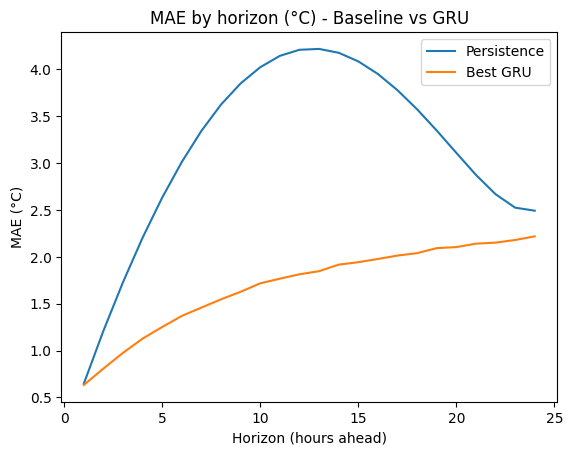

In [65]:
# Convert persistence baseline to °C
y_pred_persist_c = inverse_scale_target(y_pred_persist, scaler, feat_cols, target_col)

H = y_test.shape[1]
mae_h_p = np.mean(np.abs(y_test_c - y_pred_persist_c), axis=0)
mae_h_g = np.mean(np.abs(y_test_c - y_pred_c), axis=0)

plt.figure()
plt.plot(range(1, H+1), mae_h_p, label="Persistence")
plt.plot(range(1, H+1), mae_h_g, label="Best GRU")
plt.title("MAE by horizon (°C) - Baseline vs GRU")
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("MAE (°C)")
plt.legend()
plt.show()

## 8.2 Error Distribution (Residual Analysis)

To further analyze model performance, the distribution of prediction residuals on the test set is examined. Residuals are defined as the difference between the true temperature values and the predicted values produced by the GRU model.

The residual histogram appears approximately centered around zero, indicating that the model does not exhibit strong systematic bias in its predictions. In other words, the model is not consistently overestimating or underestimating the temperature.

Additionally, the distribution shows a roughly symmetric shape, suggesting that positive and negative errors occur with similar frequency. Most residuals are concentrated near zero, meaning that the majority of predictions are relatively close to the true temperature values.

The absolute error distribution further confirms that most prediction errors are relatively small, with only a limited number of larger deviations. This behaviour indicates that the GRU model provides generally accurate forecasts while maintaining stable performance across the test set.

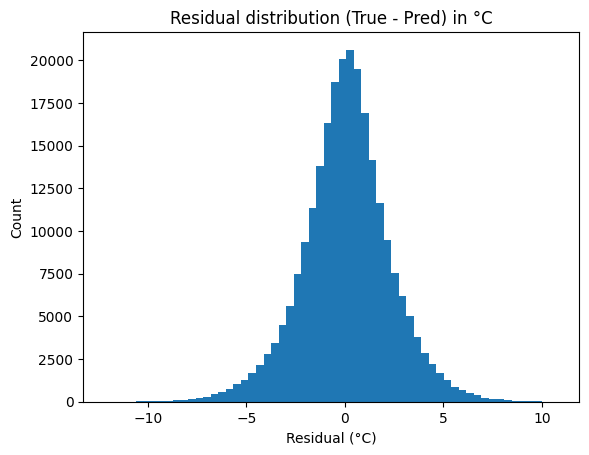

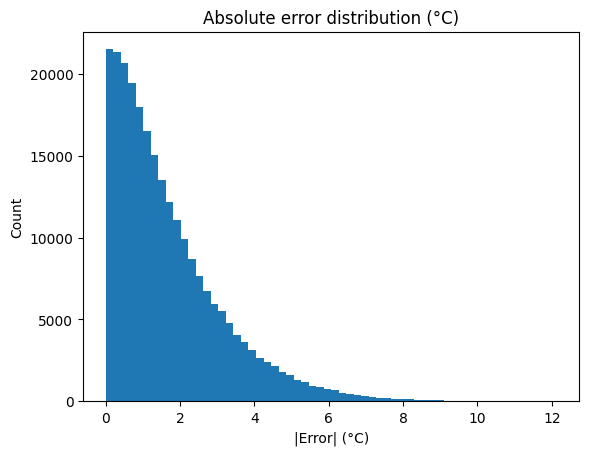

In [66]:
res = (y_test_c - y_pred_c).reshape(-1)

plt.figure()
plt.hist(res, bins=60)
plt.title("Residual distribution (True - Pred) in °C")
plt.xlabel("Residual (°C)")
plt.ylabel("Count")
plt.show()

# Absolute error distribution
abs_err = np.abs(res)
plt.figure()
plt.hist(abs_err, bins=60)
plt.title("Absolute error distribution (°C)")
plt.xlabel("|Error| (°C)")
plt.ylabel("Count")
plt.show()

## 8.3 One-Step-Ahead Forecast Visualization

To visually assess the quality of the model's predictions, a continuous segment of the test set is plotted, comparing the true temperature values with the one-step-ahead forecasts produced by the GRU model.

The plot illustrates that the predicted values closely follow the temporal dynamics of the true signal, capturing both the rising and falling patterns of the temperature series. Although small deviations between the predicted and true values can be observed, the overall trajectory remains highly consistent.

This visualization confirms that the GRU model is capable of accurately tracking short-term variations in the temperature signal, demonstrating strong predictive performance for near-term forecasts.

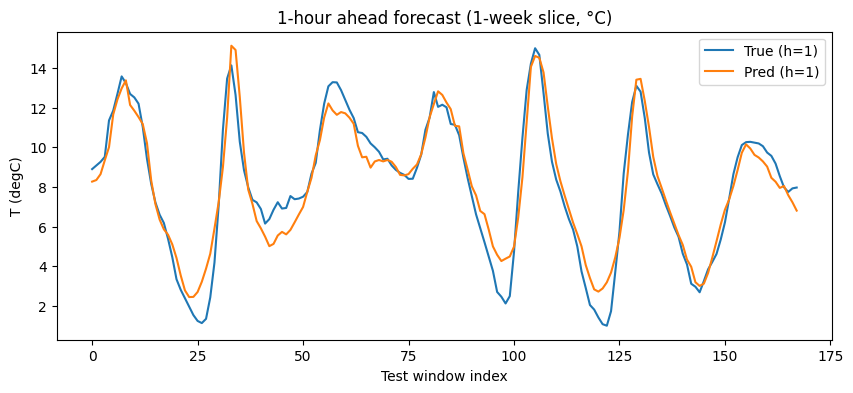

In [67]:
start = 0
n = 7 * 24  # 1 week of windows

y_true_1 = y_test_c[start:start+n, 0]
y_pred_1 = y_pred_c[start:start+n, 0]

plt.figure(figsize=(10,4))
plt.plot(y_true_1, label="True (h=1)")
plt.plot(y_pred_1, label="Pred (h=1)")
plt.title("1-hour ahead forecast (1-week slice, °C)")
plt.xlabel("Test window index")
plt.ylabel("T (degC)")
plt.legend()
plt.show()

## 8.4 Multi-Step Forecast Trajectories

To better understand the model's behaviour across longer prediction horizons, several 24-hour forecast trajectories are visualized for different examples in the test set.

Each plot compares the true temperature evolution with the sequence of predictions generated by the GRU model for the full forecasting horizon. These examples illustrate how the model performs when predicting multiple future time steps simultaneously.

In general, the predicted trajectories follow the overall trends of the true temperature curves, although deviations become more noticeable as the horizon increases. This behaviour is expected in multi-step forecasting tasks, where uncertainty accumulates as predictions extend further into the future.

Despite this increasing uncertainty, the GRU model still captures the main dynamics of the temperature evolution, demonstrating its ability to learn meaningful temporal patterns from the historical data.

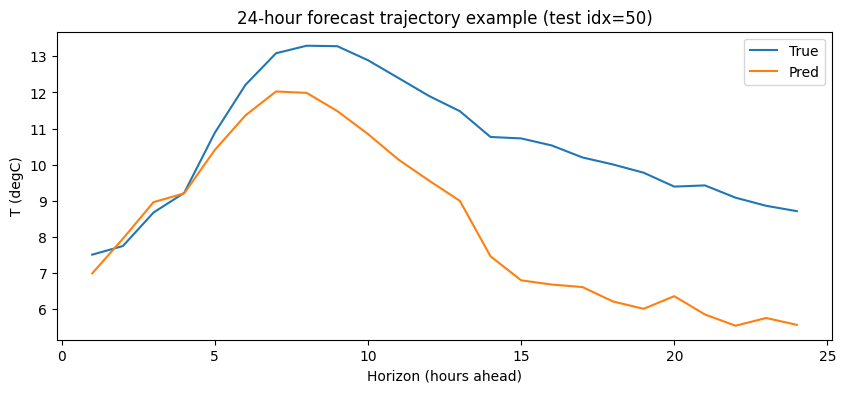

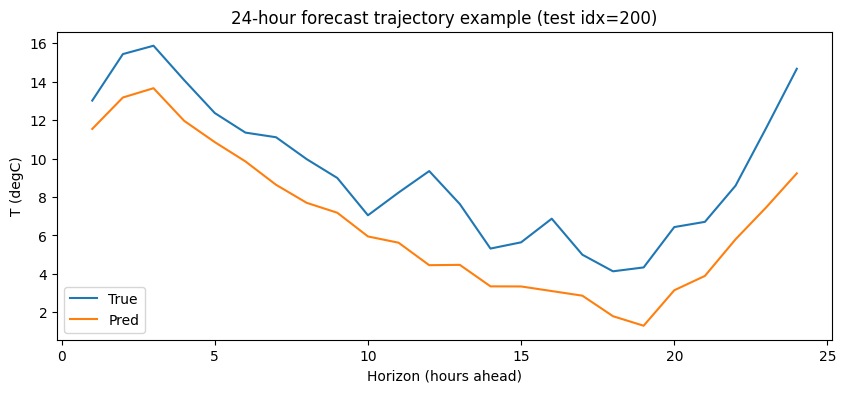

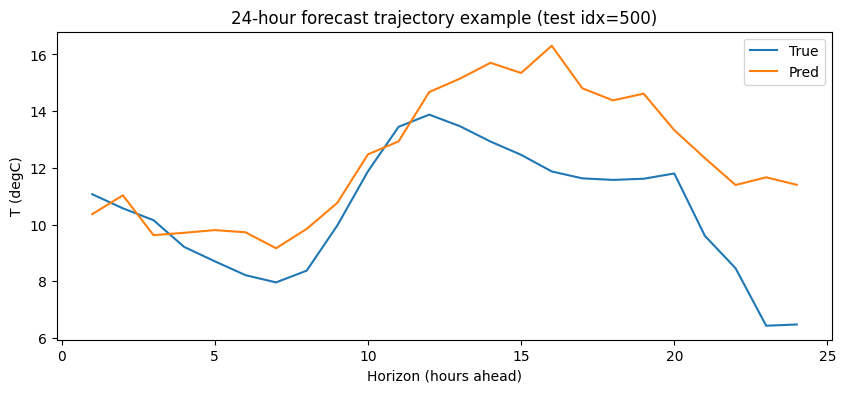

In [68]:
examples = [50, 200, 500]  # pick any indices within test

for i in examples:
    plt.figure(figsize=(10,4))
    plt.plot(range(1, H+1), y_test_c[i], label="True")
    plt.plot(range(1, H+1), y_pred_c[i], label="Pred")
    plt.title(f"24-hour forecast trajectory example (test idx={i})")
    plt.xlabel("Horizon (hours ahead)")
    plt.ylabel("T (degC)")
    plt.legend()
    plt.show()

## 8.5 Learning Curves of the Best Configurations

To analyze the training dynamics of the most promising configurations, the learning curves of the top-performing models are examined. These curves show the evolution of both training loss and validation loss over the training epochs.

In all three cases, the training loss decreases steadily as the model learns from the data, while the validation loss stabilizes after a small number of epochs. This behaviour indicates that the models converge efficiently during training.

The relatively small gap between training and validation loss suggests that the models do not suffer from severe overfitting and are able to generalize reasonably well to unseen data.

Overall, the learning curves confirm that the selected hyperparameter configurations lead to stable training dynamics and effective optimization of the GRU forecasting model.

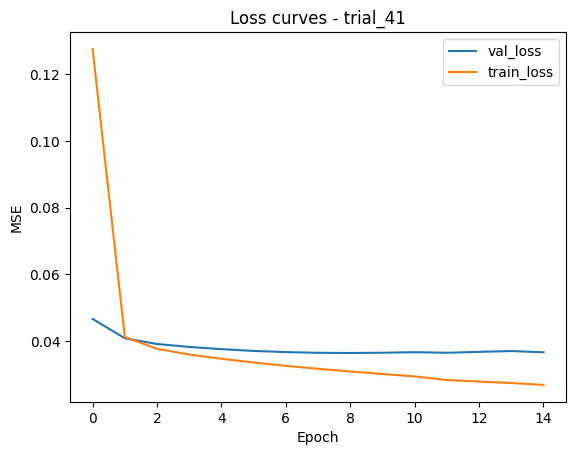

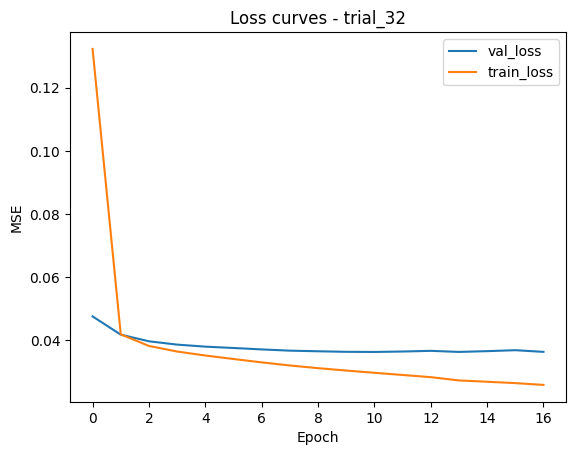

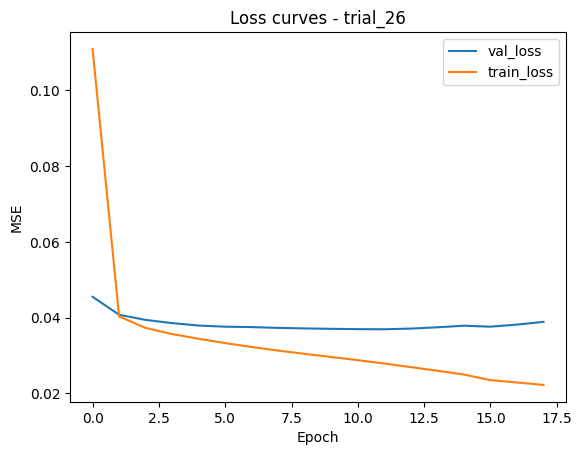

In [69]:
# Retrain top-3 configs to visualise their learning curves.
# config_keys comes from the Optuna study so all sampled parameters are included.
config_keys = list(study.best_params.keys())

top3 = results_df.head(3).to_dict(orient="records")
histories = []

for cfg_row in top3:
    cfg = {k: cfg_row[k] for k in config_keys if k in cfg_row}
    model, history, best_val_loss, best_val_mae = train_one_config(
        cfg, X_train, y_train, X_val, y_val, max_epochs=40
    )
    histories.append((cfg_row["name"], history.history))

for name, h in histories:
    plt.figure()
    plt.plot(h["val_loss"],  label="val_loss")
    plt.plot(h["loss"],      label="train_loss")
    plt.title(f"Loss curves - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()


# 9. Forecasting

Beyond evaluating the predictive performance of the GRU architecture, an important objective of time series models is their ability to generate future forecasts from the most recent observations. In practical applications, forecasting models are used to estimate upcoming values of the target variable based on the latest available data.

This section demonstrates how the trained GRU model can be applied to produce temperature forecasts. Using the most recent observations from the dataset, the model generates predictions for the upcoming time horizon, providing an estimate of the expected evolution of temperature over time.

## 9.1 Generating a 24-Hour Temperature Forecast

To produce a future forecast, the last input window used by the model is constructed from the most recent observations in the dataset. This window contains the same set of features and temporal structure used during training, ensuring consistency between training and inference.

The input window is first transformed using the previously fitted scaler so that the data is represented in the same normalized space used by the model. The scaled window is then provided to the trained GRU network, which generates a sequence of predictions corresponding to the next 24 hours.

Since the model outputs predictions in the scaled space, the results are transformed back to the original temperature scale using the inverse transformation. Finally, the predicted values are associated with their corresponding future timestamps and visualized as a continuous temperature forecast.

/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


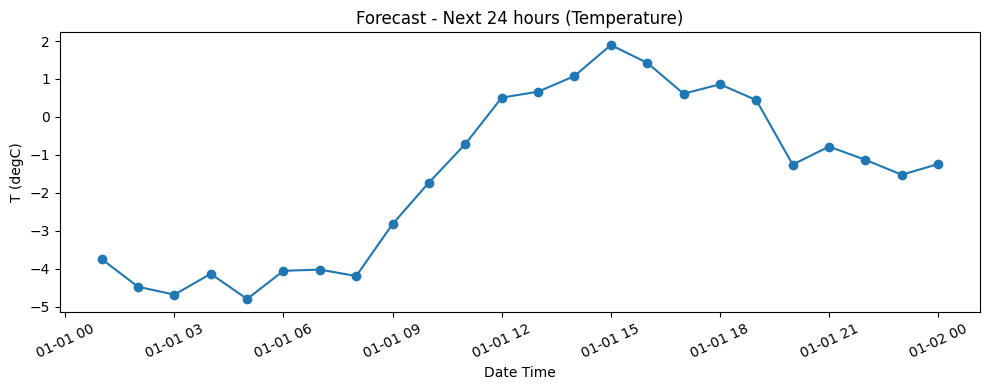

,Date Time,T_forecast_degC
0,2017-01-01 01:00:00,-3.742557
1,2017-01-01 02:00:00,-4.472740
2,2017-01-01 03:00:00,-4.680115
3,2017-01-01 04:00:00,-4.131474
4,2017-01-01 05:00:00,-4.795794
5,2017-01-01 06:00:00,-4.052314
6,2017-01-01 07:00:00,-4.020686
7,2017-01-01 08:00:00,-4.190024
8,2017-01-01 09:00:00,-2.820414
9,2017-01-01 10:00:00,-1.727343


,Date Time,T_forecast_degC
14,2017-01-01 15:00:00,1.894389
15,2017-01-01 16:00:00,1.426763
16,2017-01-01 17:00:00,0.611912
17,2017-01-01 18:00:00,0.859941
18,2017-01-01 19:00:00,0.442973
19,2017-01-01 20:00:00,-1.254681
20,2017-01-01 21:00:00,-0.779901
21,2017-01-01 22:00:00,-1.130151
22,2017-01-01 23:00:00,-1.522685
23,2017-01-02 00:00:00,-1.240787


In [70]:
# 2.1) Build last input window (L hours) from the end of the dataset
df_full = df_work.copy()  # df_work: hourly clean, index=Date Time, columns=features (unscaled)

# If you engineered features during training, apply the same here:
df_full_fe = add_time_features(df_full)

# Keep the same columns and order used in scaling/training
df_full_fe = df_full_fe[feat_cols].copy()

# Take last L rows
last_window = df_full_fe.iloc[-L:].copy()

# Scale
last_window_scaled = scaler.transform(last_window.values)

# Model input shape: (1, L, n_features)
X_last = last_window_scaled.reshape(1, L, len(feat_cols))

# Predict next 24h (scaled)
y_next24_scaled = best_gru.predict(X_last, verbose=0)  # shape (1, 24)

# Inverse scale to °C
y_next24_c = inverse_scale_target(y_next24_scaled, scaler, feat_cols, target_col).flatten()

# Build future datetime index
last_time = df_full_fe.index[-1]
future_index_24 = pd.date_range(start=last_time + pd.Timedelta(hours=1), periods=H, freq="1h")

# Plot forecast
plt.figure(figsize=(10,4))
plt.plot(future_index_24, y_next24_c, marker="o")
plt.title("Forecast - Next 24 hours (Temperature)")
plt.xlabel("Date Time")
plt.ylabel("T (degC)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# Show as table
forecast_24h = pd.DataFrame({"Date Time": future_index_24, "T_forecast_degC": y_next24_c})
display(forecast_24h.head(10))
display(forecast_24h.tail(10))

## 9.2 Five-Day Forecasting

To further evaluate the practical forecasting capability of the trained model, a longer prediction horizon is considered by generating a five-day temperature forecast. Since the GRU model produces predictions in blocks of 24 hours, a rolling forecasting strategy is used to iteratively extend the prediction horizon.

At each step, the model predicts the next 24 hours based on the most recent available input window. The newly predicted temperature values are then appended to the simulated dataset, allowing them to serve as inputs for subsequent predictions. This procedure is repeated until the full five-day horizon (120 hours) is generated.

For exogenous meteorological variables such as pressure, humidity, and wind-related measurements, future values are approximated using observations from a previous time lag. This approach leverages the strong weekly periodicity typically present in meteorological data and provides a reasonable proxy for unknown future measurements.

The resulting forecast represents a continuous multi-day temperature trajectory generated by the GRU model, illustrating how the trained architecture can be used to produce longer-term predictions beyond the original 24-hour prediction horizon.

In [71]:
def forecast_rolling_5days(df_full_raw, best_model, scaler, feat_cols, target_col, L=120, H=24, days=5, lag_hours=168):
    steps = days * 24  # total future hours
    n_blocks = steps // H

    df_sim = df_full_raw.copy()
    preds_all = []
    last_time = df_sim.index[-1]

    for b in range(n_blocks):
        # Recompute time features over current (growing) df_sim
        df_sim_fe = add_time_features(df_sim)

        # Use last L hours as model input
        X_win = df_sim_fe[feat_cols].iloc[-L:].values
        X_win_s = scaler.transform(X_win).reshape(1, L, len(feat_cols))

        y_block_s = best_model.predict(X_win_s, verbose=0)  # (1, H)
        y_block_c = inverse_scale_target(y_block_s, scaler, feat_cols, target_col).flatten()

        # Future timestamps for this block
        start = last_time + pd.Timedelta(hours=1)
        idx = pd.date_range(start=start, periods=H, freq="1h")

        preds_all.append(pd.DataFrame({"Date Time": idx, "T_forecast_degC": y_block_c}))

        # Seasonal-naive imputation for exogenous features:
        # For each future hour t, use the observed values from lag_hours ago (default: 168h = 7 days).
        # This is physically motivated: atmospheric variables (pressure, humidity, wind)
        # exhibit strong weekly periodicity, making same-hour-last-week a better
        # proxy than freezing the last observed value indefinitely.
        for t, yv in zip(idx, y_block_c):
            lag_time = t - pd.Timedelta(hours=lag_hours)
            if lag_time in df_sim.index:
                new_row = df_sim.loc[[lag_time]].copy()
            else:
                new_row = df_sim.iloc[-1:].copy()  # fallback if lag not in history
            new_row.index = [t]
            new_row[target_col] = yv  # temperature always from model prediction
            df_sim = pd.concat([df_sim, new_row])

        last_time = idx[-1]

    return pd.concat(preds_all, ignore_index=True)

forecast_5d = forecast_rolling_5days(df_work, best_gru, scaler, feat_cols, target_col, L=L, H=H, days=5)
display(forecast_5d.head())
display(forecast_5d.tail())

/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: U

,Date Time,T_forecast_degC
0,2017-01-01 01:00:00,-3.742557
1,2017-01-01 02:00:00,-4.472740
2,2017-01-01 03:00:00,-4.680115
3,2017-01-01 04:00:00,-4.131474
4,2017-01-01 05:00:00,-4.795794


,Date Time,T_forecast_degC
115,2017-01-05 20:00:00,1.189634
116,2017-01-05 21:00:00,0.996627
117,2017-01-05 22:00:00,0.699103
118,2017-01-05 23:00:00,0.316859
119,2017-01-06 00:00:00,0.098256


### 9.2.1 Five-Day Temperature Forecast

To extend the forecasting horizon beyond the initial 24-hour prediction window, a rolling forecasting strategy is applied to generate a five-day temperature forecast. The model iteratively predicts the next 24 hours and then incorporates these predictions into the input sequence to produce subsequent forecasts.

The resulting predictions are combined to form a continuous temperature trajectory covering the next 120 hours (5 days). This approach allows the model to simulate longer-term forecasts while maintaining the same temporal structure used during training.

The figure below illustrates the predicted evolution of temperature over the five-day horizon. The forecast exhibits smooth temporal patterns that resemble realistic daily temperature cycles, indicating that the GRU model captures meaningful temporal dynamics in the data.

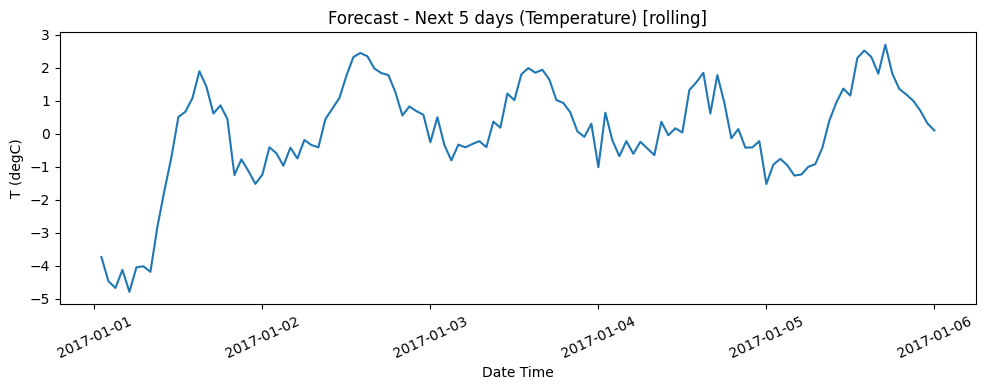

In [72]:
plt.figure(figsize=(10,4))
plt.plot(forecast_5d["Date Time"], forecast_5d["T_forecast_degC"])
plt.title("Forecast - Next 5 days (Temperature) [rolling]")
plt.xlabel("Date Time")
plt.ylabel("T (degC)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()